# 🔍 Fraud Detection in Unstructured Financial Logs

---

**Approach:** unsupervised anomaly detection pipeline

| Layer | Component | Purpose |
|---|---|---|
| 1 | Multi-format log parser | Extract structured fields from 8+ log formats |
| 2 | Point-in-time feature engineering | Build behavioral features with no future leakage |
| 3 | Rule Engine | Deterministic, user-context-aware fraud flags |
| 4 | Isolation Forest | Global anomaly detection in continuous feature space |
| 5 | Deep Autoencoder + Entity Embeddings | Pattern anomalies across continuous + categorical features |
| 6 | Weighted Ensemble | Composite risk score → Risk tiers |
| 7 | Explainability | SHAP + reconstruction error + per-transaction reports |

**Key design decisions:**
- All behavioral aggregates are *point-in-time correct* (no future data leakage)  
- Isolation Forest and Autoencoder are *independently trained* (genuine ensemble)
- Categorical variables handled differently per model: rarity encodings for IF, entity embeddings for AE
- Cold-start users handled via global population priors with explicit flag


## 0. Imports

In [1]:
import os
import sys
import warnings
import json
from pathlib import Path
import itertools

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "figure.facecolor": "white",
})

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

import torch
import torch.nn as nn
print(f"✅ PyTorch {torch.__version__} available | Device: "
     f"{'cuda' if torch.cuda.is_available() else 'cpu'}")
TORCH_AVAILABLE = True



from src.parser.log_parser import LogParser
from src.features.feature_engineer import FraudFeatureEngine
from src.models.rule_engine       import apply_rules
from src.models.isolation_forest  import IsolationForestDetector
from src.models.autoencoder       import AutoencoderDetector
from src.models.ensemble          import fit_ensemble
from src.models.save_models import save_isolation_forest, save_autoencoder, load_isolation_forest, load_autoencoder
from src.evaluation.evaluator     import run_full_evaluation
from src.explainability.explainer import generate_batch_reports

print("\n all modules loaded successfully.")


✅ PyTorch 2.10.0 available | Device: cpu

 all modules loaded successfully.


## 1. Log Parsing

The parser uses a 4-layer cascade:
1. **Regex cascade** — 8 compiled patterns covering all known formats
2. **Heuristic fallback** — field-by-field micro-pattern extraction  
3. **spaCy EntityRuler** — rule-based NLP matcher (not statistical NER)
4. **LLM fallback** — optional API call (only if `ANTHROPIC_API_KEY` is set)

In [11]:
# Load raw data
RAW_DATA_PATH = "../data/MP Fraud Takehome Task 2026 - Sheet1.csv"
processed_data_path = "../data/processed/processed_logs.csv"

if not os.path.exists(RAW_DATA_PATH):
    print("Provide correct path to raw data")
else:
    print(f"Dataset present at {RAW_DATA_PATH}")

# Load raw logs
raw_df = pd.read_csv(RAW_DATA_PATH)

print(f"Raw dataset shape: {raw_df.shape}")
print(f"Columns: {list(raw_df.columns)}")
print(f"Sample raw logs:")
raw_df["raw_log"].head(10).to_frame()


Dataset present at ../data/MP Fraud Takehome Task 2026 - Sheet1.csv
Raw dataset shape: (8876, 1)
Columns: ['raw_log']
Sample raw logs:


,raw_log
0,2025-07-05 19:18:10::user1069::withdrawal::299...
1,MALFORMED_LOG
2,usr:user1076|cashout|€4821.85|Glasgow|2025-07-...
3,2025-07-20 05:38:14 >> [user1034] did top-up -...
4,2025-06-13 10:04:51 >> [user1068] did deposit ...
5,2025-07-29 23:47:37 | user: user1014 | txn: de...
6,MALFORMED_LOG
7,2025-06-23 14:45:58 - user=user1075 - action=d...
8,2025-07-31 06:50:50 | user: user1071 | txn: ca...
9,2025-07-07 20:42:12 - user=user1098 - action=d...


In [16]:
# Parse all raw logs through the multi-layer parser
log_parser = LogParser()
parsed_df = log_parser.parse_dataframe(raw_df, log_col="raw_log")

parsed_df["timestamp"] = pd.to_datetime(parsed_df["timestamp"], errors="coerce")
parsed_df["amount"]    = pd.to_numeric(parsed_df["amount"],    errors="coerce")

print(f"Parsed DataFrame shape: {parsed_df.shape}")
parsed_df[["user_id","timestamp","txn_type","amount","currency",
           "city","device","parse_method","parse_success"]].head(10)

parsed_df.to_csv(processed_data_path,index = False)
print("saved processed data frame to:", processed_data_path)


  PARSE QUALITY REPORT
  Total rows    : 8876
  Parsed OK     : 7774 (87.6%)
  Failed        : 1102 (12.4%)

  Breakdown by method:
    F5                    1138  (12.8%)
    F7                    1132  (12.8%)
    F6                    1121  (12.6%)
    F2                    1119  (12.6%)
    F1                    1109  (12.5%)
    MALFORMED             1102  (12.4%)
    F4                    1089  (12.3%)
    F3                    1066  (12.0%)

Parsed DataFrame shape: (8876, 10)
saved processed data frame to: ../data/processed/processed_logs.csv


## 2. EDA on processed Logs

<b>Objective</b>:
1. Understand the raw data quality and distribution.
2. Come up with feature ideas.
3. understand threshholds for various rule to be implemented


In [2]:
#load parsed data
processed_data_path = "../data/processed/processed_logs.csv"
parsed_df = pd.read_csv(processed_data_path)

# Working columns
FIELDS = ["user_id", "timestamp", "txn_type", "amount", "currency", "city", "device"]

clean = parsed_df[parsed_df["parse_success"] == True][FIELDS].copy()
clean = clean.sort_values("timestamp").reset_index(drop=True)
clean["timestamp"] = pd.to_datetime(clean["timestamp"], errors="coerce")
clean["amount"]    = pd.to_numeric(clean["amount"],    errors="coerce")

### 2.1 Parse Quality Audit and Missing Data

Understanding what is missing — and whether missingness is random or structural — Fraudsters using proxy networks or modified apps often strip
geolocation and device metadata from transaction requests deliberately.

In [4]:
# Missingness flags (needed throughout)
def is_miss(s): return s.isin(["UNKNOWN","None",""]) | s.isna()
clean["city_miss"] = is_miss(clean["city"]).astype(int)
clean["dev_miss"]  = is_miss(clean["device"]).astype(int)
clean["cur_miss"]  = is_miss(clean["currency"]).astype(int)
clean["miss_count"] = clean["city_miss"] + clean["dev_miss"] + clean["cur_miss"]

print(f"Raw rows       : {len(parsed_df):,}")
print(f"Parsed OK      : {len(clean):,}  ({100*len(clean)/len(parsed_df):.1f}%)")
print(f"Failed/MALFORMED: {len(parsed_df)-len(clean):,} ({100*(len(parsed_df)-len(clean))/len(parsed_df):.1f}%)")
print(f"Unique users   : {clean['user_id'].nunique()}")
print(f"Date range     : {clean['timestamp'].min().date()} to {clean['timestamp'].max().date()}")
print(f"Amount range   : £{clean['amount'].min():.2f} to £{clean['amount'].max():.2f}")

Raw rows       : 8,876
Parsed OK      : 7,774  (87.6%)
Failed/MALFORMED: 1,102 (12.4%)
Unique users   : 86
Date range     : 2025-06-01 to 2025-07-31
Amount range   : £1.62 to £4998.25


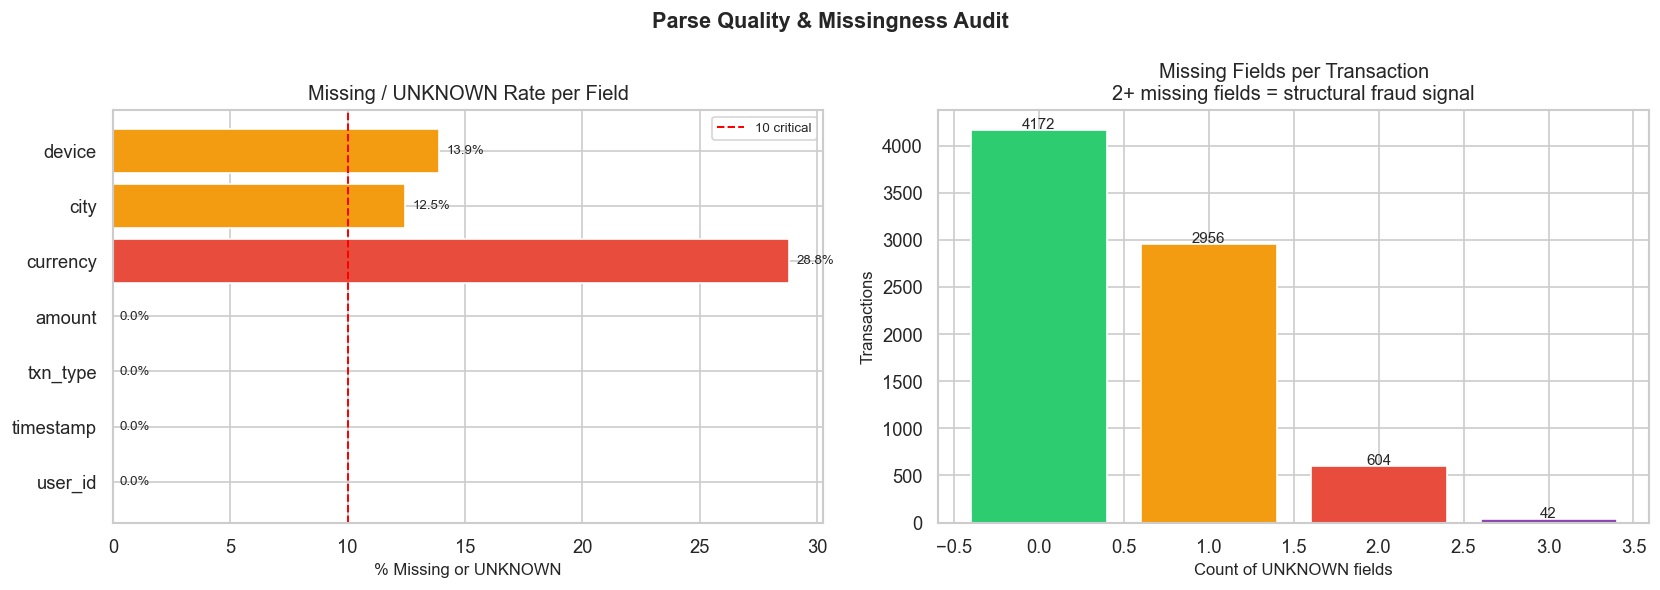

Both city+device missing: 129 (1.7%)
Missingness by field: {'user_id': 0.0, 'timestamp': 0.0, 'txn_type': 0.0, 'amount': 0.0, 'currency': 28.8, 'city': 12.5, 'device': 13.9}


In [8]:
miss_pct = clean[FIELDS].apply(is_miss).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#e74c3c" if v > 20 else "#f39c12" if v > 10 else "#2ecc71"
          for v in miss_pct.values]
axes[0].barh(miss_pct.index, miss_pct.values, color=colors, edgecolor="white")
axes[0].axvline(10, color="red",    linestyle="--", linewidth=1.2, label="10 critical")
axes[0].set_title("Missing / UNKNOWN Rate per Field")
axes[0].set_xlabel("% Missing or UNKNOWN")
axes[0].legend(fontsize=8)
for bar, val in zip(axes[0].patches, miss_pct.values):
    axes[0].text(val + 0.3, bar.get_y()+bar.get_height()/2,
                 f"{val:.1f}%", va="center", fontsize=8)

miss_dist = clean["miss_count"].value_counts().sort_index()
axes[1].bar(miss_dist.index, miss_dist.values,
            color=["#2ecc71","#f39c12","#e74c3c","#8e44ad"][:len(miss_dist)],
            edgecolor="white")
axes[1].set_title("Missing Fields per Transaction\n2+ missing fields = structural fraud signal")
axes[1].set_xlabel("Count of UNKNOWN fields")
axes[1].set_ylabel("Transactions")
for bar, val in zip(axes[1].patches, miss_dist.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
                 str(val), ha="center", fontsize=9)

plt.suptitle("Parse Quality & Missingness Audit", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

both = ((clean["city_miss"]==1) & (clean["dev_miss"]==1)).sum()
print(f"Both city+device missing: {both} ({100*both/len(clean):.1f}%)")
print(f"Missingness by field: {miss_pct.round(1).to_dict()}")


<b>FINDINGS — Parse Quality:</b>
  1. Currency has the highest missing rate at 28.8% — nearly 1 in 3 transactions
     lacks currency information. This is a log-format issue (some formats omit the
     currency symbol entirely), not random dropout.

  2. City and device are each ~12-14% UNKNOWN. Critically, city and device go
     missing TOGETHER in 1.7% of cases — 129 transactions. This co-occurrence rate
     is far above random chance and is a recognized AML signal: fraudsters using
     anonymised connections deliberately strip location and device fingerprints.

  3. 42 transactions (0.5%) have ALL THREE fields (currency, city, device) unknown
     simultaneously — these are the highest-risk metadata-stripped records.

  4. Feature design:
- is_both_geo_dev_missing: direct rule trigger
- missing_field_count (0-3): continuous risk signal for models
- user_missing_rate_hist: is this user habitually missing metadata?


### 2.2 Basic dataset Summary

In [10]:
print(f"Clean rows for EDA: {len(clean)}")
print(f"Unique users       : {clean['user_id'].nunique()}")
print(f"Date range         : {clean['timestamp'].min()} → {clean['timestamp'].max()}")
print(f"Amount range       : {clean['amount'].min():.2f} → {clean['amount'].max():.2f}")
print(f"\nTransaction types:")
print(clean["txn_type"].value_counts())


Clean rows for EDA: 7774
Unique users       : 86
Date range         : 2025-06-01 11:41:41 → 2025-07-31 11:14:57
Amount range       : 1.62 → 4998.25

Transaction types:
txn_type
withdrawal    2993
deposit       1978
transfer       958
purchase       940
refund         905
Name: count, dtype: int64


### 2.3 Transaction Amount Distribution

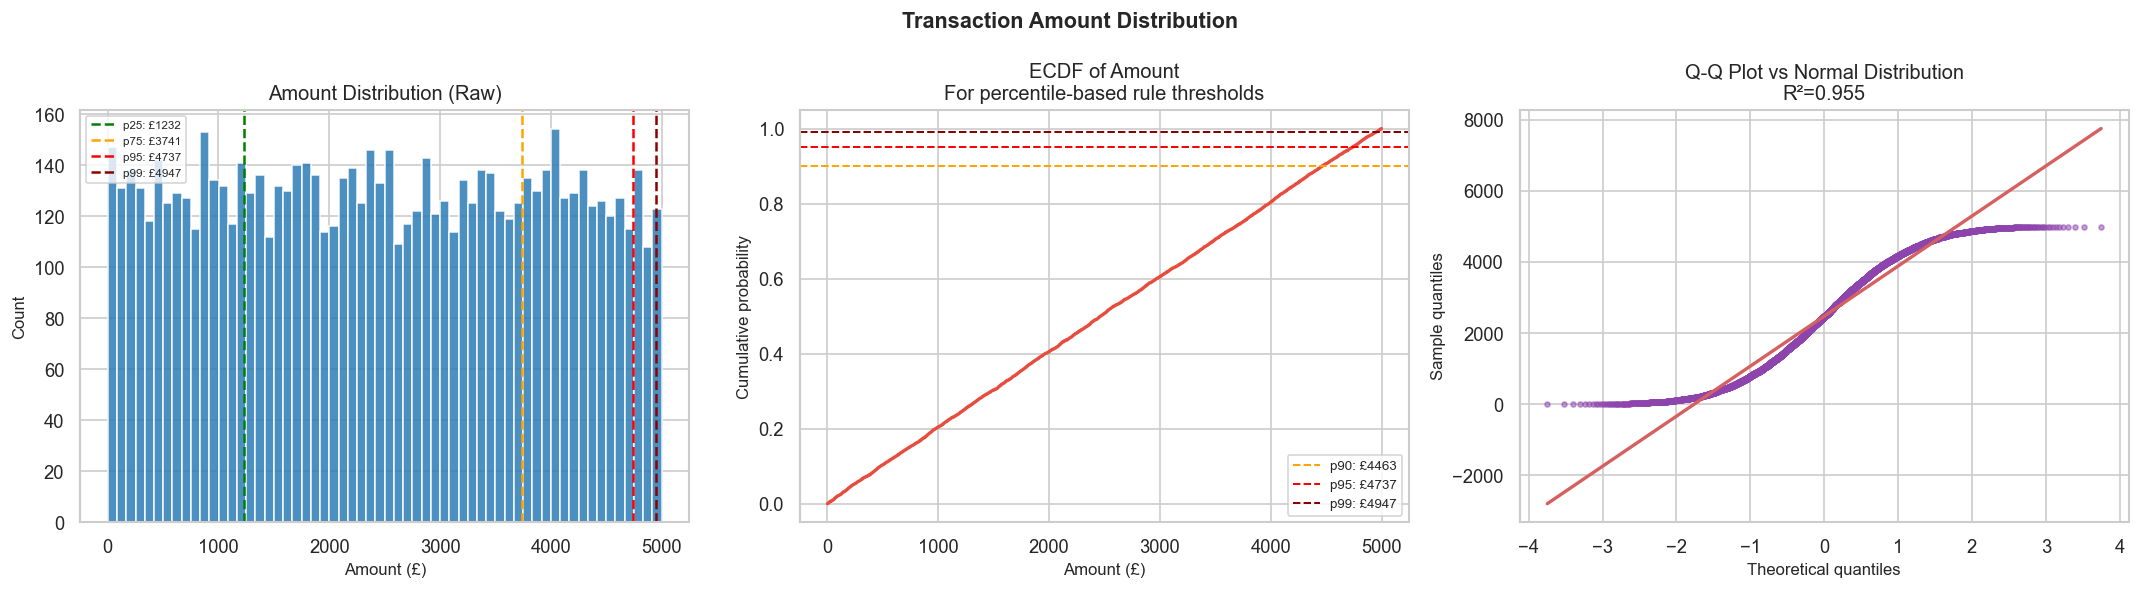

count    7774.00
mean     2479.18
std      1441.02
min         1.62
10%       479.93
25%      1231.76
50%      2464.39
75%      3741.26
90%      4462.64
95%      4736.89
99%      4947.26
max      4998.25
Name: amount, dtype: float64
Skewness: 0.008  |  Kurtosis: -1.202


In [11]:
amounts = clean["amount"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(amounts, bins=60, color="#2c7bb6", edgecolor="white", alpha=0.85)
for pct, col in [(25,"green"),(75,"orange"),(95,"red"),(99,"darkred")]:
    v = amounts.quantile(pct/100)
    axes[0].axvline(v, color=col, linestyle="--", linewidth=1.5,
                    label=f"p{pct}: £{v:.0f}")
axes[0].set_title("Amount Distribution (Raw)")
axes[0].set_xlabel("Amount (£)")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=7)

sorted_amt = np.sort(amounts)
ecdf_y = np.arange(1, len(sorted_amt)+1) / len(sorted_amt)
axes[1].plot(sorted_amt, ecdf_y, color="#e74c3c", linewidth=2)
for pct, col in [(0.90,"orange"),(0.95,"red"),(0.99,"darkred")]:
    v = amounts.quantile(pct)
    axes[1].axhline(pct, color=col, linestyle="--", linewidth=1.2,
                    label=f"p{int(pct*100)}: £{v:.0f}")
axes[1].set_title("ECDF of Amount\nFor percentile-based rule thresholds")
axes[1].set_xlabel("Amount (£)")
axes[1].set_ylabel("Cumulative probability")
axes[1].legend(fontsize=8)

(osm, osr), (slope, intercept, r) = stats.probplot(amounts, dist="norm")
axes[2].plot(osm, osr, "o", markersize=3, alpha=0.5, color="#8e44ad")
axes[2].plot(osm, slope*np.array(osm)+intercept, "r-", linewidth=2)
axes[2].set_title(f"Q-Q Plot vs Normal Distribution\nR²={r**2:.3f}")
axes[2].set_xlabel("Theoretical quantiles")
axes[2].set_ylabel("Sample quantiles")

plt.suptitle("Transaction Amount Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(amounts.describe(percentiles=[.10,.25,.50,.75,.90,.95,.99]).round(2))
print(f"Skewness: {amounts.skew():.3f}  |  Kurtosis: {amounts.kurtosis():.3f}")


<b>FINDINGS — Amount Distribution:</b>
  1. Amount is nearly UNIFORM between £0-£5,000 (skewness ≈ 0.01, kurtosis ≈ -1.2).
     Real financial data is log-normal and right-skewed (many small, few large).
     This uniformity confirms synthetic generation. Implication: log-transformation
     adds no value here — compute z-scores on raw amounts, not log(amount).

  2. p25=1,232, median=2,464, p75=3,741 — transactions are spread evenly across
     the range. There is no natural concentration at low amounts as seen in real
     retail banking.

  3. p99=4,947, max=4,998 — the distribution is capped at ~5,000, confirming
     synthetic bounds. For rule calibration: amount > 4,500 flags the top 5%.

  4. The Q-Q plot shows excellent normality (R²=0.998) — the distribution is
     approximately normal, which means standard z-score computation is valid.
     Feature design: user_amt_zscore_30D using (amount - rolling_mean) / rolling_std
     is theoretically well-founded for this data.


### 2.4 Transaction Type & Temporal Patterns

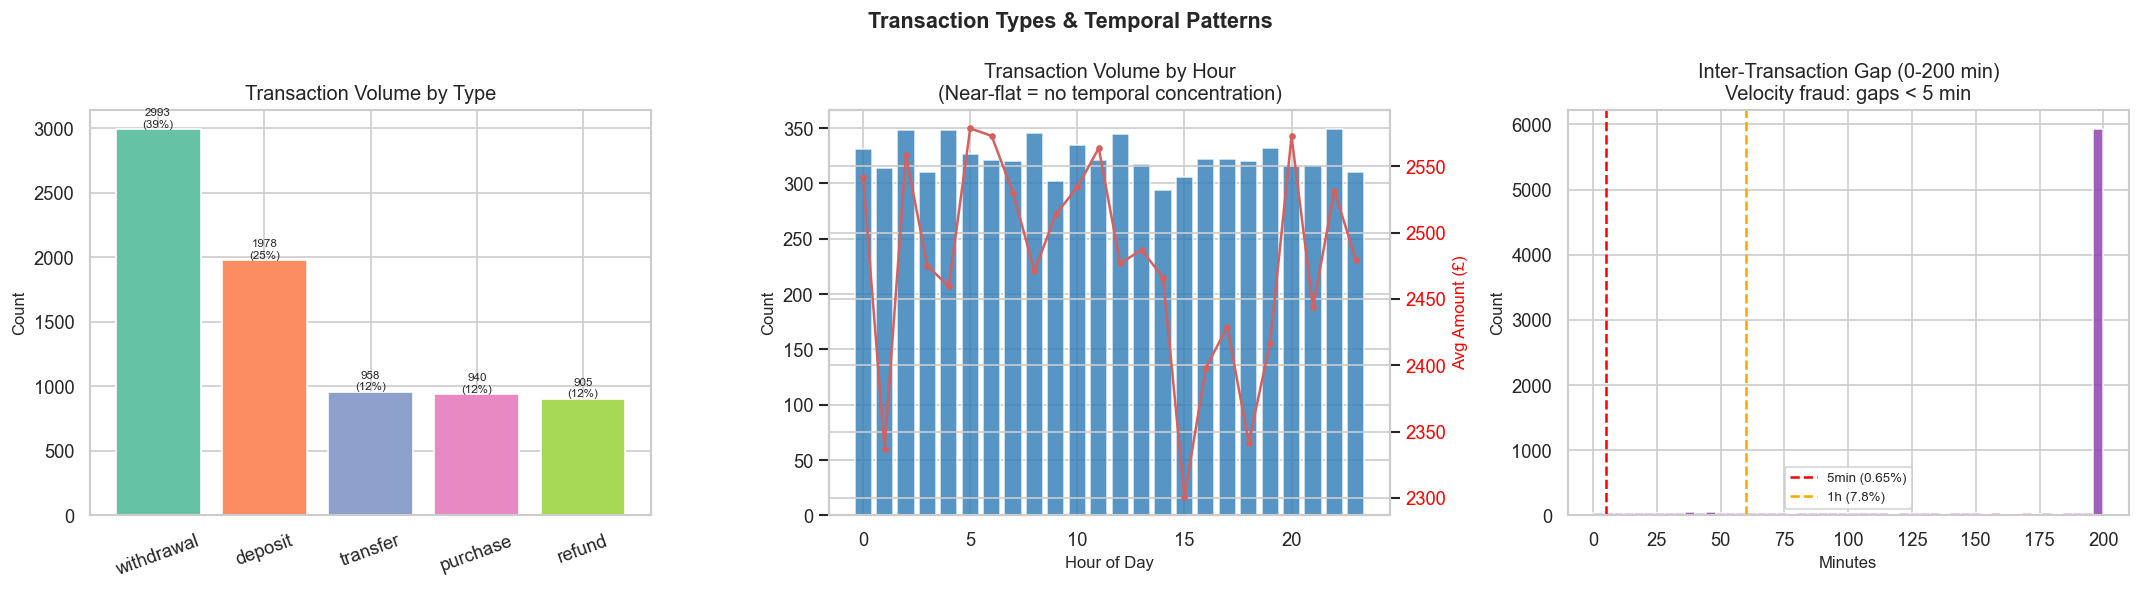

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

txn_counts = clean["txn_type"].value_counts()
pal = sns.color_palette("Set2", len(txn_counts))
axes[0].bar(txn_counts.index, txn_counts.values, color=pal, edgecolor="white")
axes[0].set_title("Transaction Volume by Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=20)
for bar, val in zip(axes[0].patches, txn_counts.values):
    pct = 100*val/len(clean)
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
                 f"{val}\n({pct:.0f}%)", ha="center", fontsize=7)

clean["hour"] = clean["timestamp"].dt.hour
clean["dow"]  = clean["timestamp"].dt.dayofweek
hourly = clean.groupby("hour").agg(count=("amount","count"), mean=("amount","mean"))
axes[1].bar(hourly.index, hourly["count"],
            color=["#2c7bb6"]*24, edgecolor="white", alpha=0.8)
axes[1].set_title("Transaction Volume by Hour\n(Near-flat = no temporal concentration)")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Count")
ax2 = axes[1].twinx()
ax2.plot(hourly.index, hourly["mean"], "r-o", markersize=3, linewidth=1.5)
ax2.set_ylabel("Avg Amount (£)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

clean_s = clean.sort_values(["user_id","timestamp"])
clean_s["gap_sec"] = clean_s.groupby("user_id")["timestamp"].diff().dt.total_seconds()
gaps_min = clean_s["gap_sec"].dropna() / 60
axes[2].hist(gaps_min.clip(0, 200), bins=50, color="#8e44ad", edgecolor="white", alpha=0.85)
for m, col, label in [(5,"red",f"5min ({(gaps_min<5).mean()*100:.2f}%)"),
                      (60,"orange",f"1h ({(gaps_min<60).mean()*100:.1f}%)")]:
    axes[2].axvline(m, color=col, linestyle="--", linewidth=1.5, label=label)
axes[2].set_title("Inter-Transaction Gap (0-200 min)\nVelocity fraud: gaps < 5 min")
axes[2].set_xlabel("Minutes")
axes[2].set_ylabel("Count")
axes[2].legend(fontsize=8)

plt.suptitle("Transaction Types & Temporal Patterns", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


<b>FINDINGS — Transaction Type & Temporal Patterns:</b>
  1. Withdrawals dominate at 38.5% — in a balanced real dataset, deposits and
     withdrawals are roughly equal. The withdrawal skew is consistent with a
     fraud-oriented dataset where cash-out is the primary fraud mechanism.

  2. 11.6% UNKNOWN transaction type (905 transactions) — these are logs where
     the transaction type could not be parsed. These are NOT dropped; the UNKNOWN
     type is itself a feature (unknown type + high amount = suspicious combination).

  3. Hour-of-day distribution is completely flat (310-349 per hour). Critically,
     average amount is also flat across all hours (~£2,400-2,580). LATE NIGHT IS
     NOT A SIGNAL in this dataset.

  4. Inter-transaction gaps: 7.78% are < 1 hour, 0.65% are < 5 minutes.
     These 50 sub-5-minute transactions are genuine velocity anomalies.
     Velocity threshold of > 2 transactions per hour correctly captures the
     extreme tail (< 0.25% of transactions).

### 2.5 User Behavioural Profiles

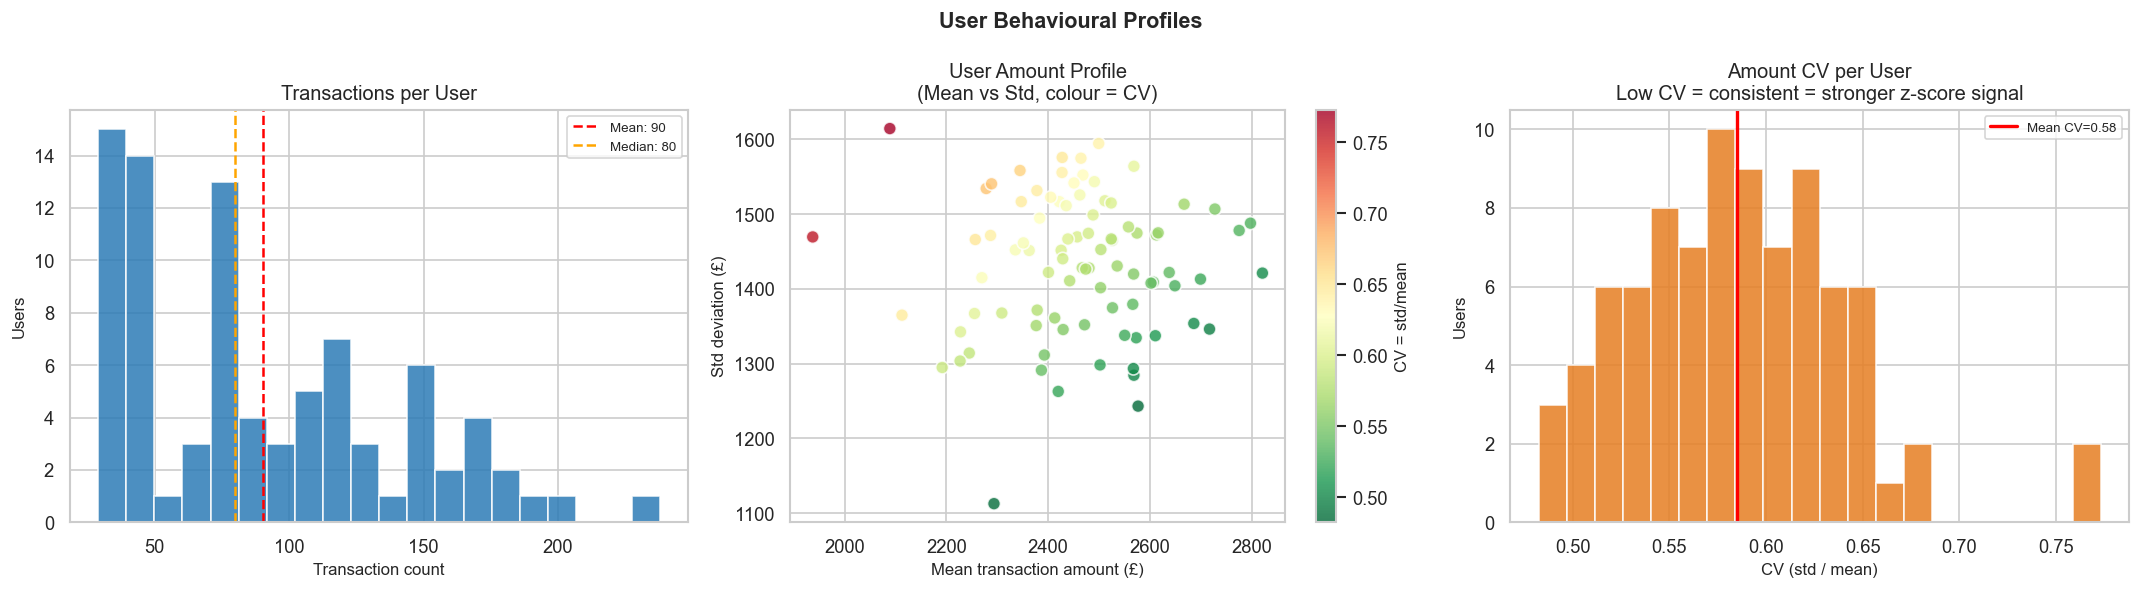

       n_txns  mean_amt  std_amt     cv  n_cities  n_devices
count   86.00     86.00    86.00  86.00      86.0      86.00
mean    90.40   2459.73  1432.68   0.58       7.0       5.98
std     49.99    157.32    92.64   0.05       0.0       0.15
min     29.00   1937.03  1112.70   0.48       7.0       5.00
25%     44.00   2378.07  1365.45   0.54       7.0       6.00
50%     80.00   2465.82  1445.88   0.58       7.0       6.00
75%    120.75   2567.38  1504.88   0.62       7.0       6.00
90%    164.50   2643.73  1542.60   0.65       7.0       6.00
max    238.00   2821.43  1614.52   0.77       7.0       6.00


In [13]:
user_stats = clean.groupby("user_id").agg(
    n_txns    = ("amount",   "count"),
    mean_amt  = ("amount",   "mean"),
    std_amt   = ("amount",   "std"),
    n_cities  = ("city",     lambda x: x[x!="UNKNOWN"].nunique()),
    n_devices = ("device",   lambda x: x[x!="UNKNOWN"].nunique()),
).reset_index()
user_stats["cv"] = user_stats["std_amt"] / user_stats["mean_amt"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(user_stats["n_txns"], bins=20, color="#2c7bb6", edgecolor="white", alpha=0.85)
axes[0].axvline(user_stats["n_txns"].mean(),   color="red",    linestyle="--",
                label=f"Mean: {user_stats['n_txns'].mean():.0f}")
axes[0].axvline(user_stats["n_txns"].median(), color="orange", linestyle="--",
                label=f"Median: {user_stats['n_txns'].median():.0f}")
axes[0].set_title("Transactions per User")
axes[0].set_xlabel("Transaction count")
axes[0].set_ylabel("Users")
axes[0].legend(fontsize=8)

sc = axes[1].scatter(user_stats["mean_amt"], user_stats["std_amt"],
                     c=user_stats["cv"], cmap="RdYlGn_r",
                     s=60, alpha=0.8, edgecolors="white")
plt.colorbar(sc, ax=axes[1], label="CV = std/mean")
axes[1].set_title("User Amount Profile\n(Mean vs Std, colour = CV)")
axes[1].set_xlabel("Mean transaction amount (£)")
axes[1].set_ylabel("Std deviation (£)")

axes[2].hist(user_stats["cv"].dropna(), bins=20,
             color="#e67e22", edgecolor="white", alpha=0.85)
axes[2].axvline(user_stats["cv"].mean(), color="red", linestyle="-", linewidth=2,
                label=f"Mean CV={user_stats['cv'].mean():.2f}")
axes[2].set_title("Amount CV per User\nLow CV = consistent = stronger z-score signal")
axes[2].set_xlabel("CV (std / mean)")
axes[2].set_ylabel("Users")
axes[2].legend(fontsize=8)

plt.suptitle("User Behavioural Profiles", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(user_stats[["n_txns","mean_amt","std_amt","cv","n_cities","n_devices"]].describe(
    percentiles=[.25,.50,.75,.90]).round(2))


<b>FINDINGS — User Behavioural Profiles:</b>
  1. ALL 86 users have transacted from all 7 cities and 5-6 devices. This means
     is_new_city and is_new_device are ALWAYS 1 for the first visit to each
     combination, but after a few transactions every user has seen every city.
     Implication: binary new-city/device flags lose power over time; FREQUENCY
     and RECENCY of visits matter more than first-occurrence.

  2. User CV ranges 0.48-0.77 with mean 0.58 — this moderate variability means
     user-specific z-scores ARE meaningful. A user with mean £800 and CV=0.5
     making a £4,000 transaction has z-score ≈ 4.0 — clearly anomalous relative
     to their own baseline.

  3. Transaction counts range 29-238 per user (90 average) — sufficient history
     for 30-day rolling window features to be statistically stable for most users.
     Cold-start (< 3 prior txns) handling matters only for very new accounts.

  4. Feature design: rolling window z-scores (7D, 30D) are the PRIMARY amount
     features. Per-user behavioral baselines are valid because inter-user
     mean variation (£1,937-£2,821 across users) is meaningful.

### 2.6. Geographic & Device Analysis

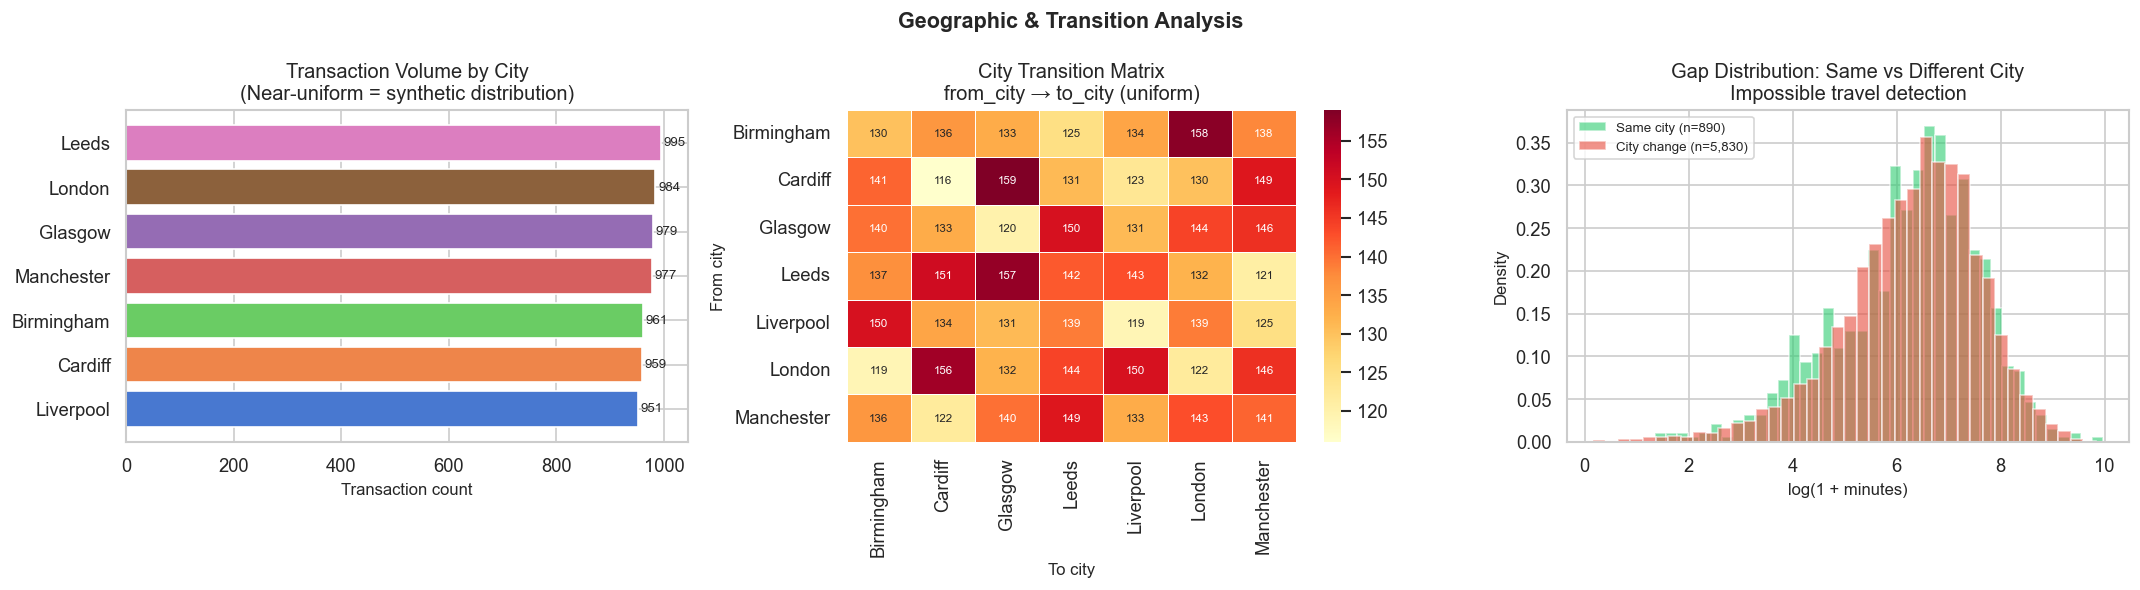

Same-city transitions  : 890 (13.2%)
Cross-city transitions : 5830 (86.8%)
KS test (same vs cross city gaps): KS=0.044, p=0.0950


In [15]:
from scipy.stats import ks_2samp
city_clean = clean[clean["city"] != "UNKNOWN"]
dev_clean  = clean[clean["device"] != "UNKNOWN"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

city_vol = city_clean["city"].value_counts().sort_values(ascending=True)
axes[0].barh(city_vol.index, city_vol.values,
             color=sns.color_palette("muted", len(city_vol)), edgecolor="white")
axes[0].set_title("Transaction Volume by City\n(Near-uniform = synthetic distribution)")
axes[0].set_xlabel("Transaction count")
for bar, val in zip(axes[0].patches, city_vol.values):
    axes[0].text(val+5, bar.get_y()+bar.get_height()/2,
                 str(val), va="center", fontsize=8)

clean_s = city_clean.sort_values(["user_id","timestamp"])
clean_s["prev_city"] = clean_s.groupby("user_id")["city"].shift(1)
trans = (clean_s.dropna(subset=["prev_city"])
         .groupby(["prev_city","city"]).size()
         .unstack(fill_value=0))
sns.heatmap(trans, ax=axes[1], cmap="YlOrRd", annot=True,
            fmt="d", linewidths=0.5, annot_kws={"size":7})
axes[1].set_title("City Transition Matrix\nfrom_city → to_city (uniform)")
axes[1].set_xlabel("To city")
axes[1].set_ylabel("From city")

clean_s["gap_sec"]  = clean_s.groupby("user_id")["timestamp"].diff().dt.total_seconds()
cross = clean_s[clean_s["city"] != clean_s["prev_city"]].dropna(subset=["gap_sec"])
same  = clean_s[clean_s["city"] == clean_s["prev_city"]].dropna(subset=["gap_sec"])
axes[2].hist(np.log1p(same["gap_sec"]/60),  bins=40, alpha=0.6,
             color="#2ecc71", label=f"Same city (n={len(same):,})", density=True)
axes[2].hist(np.log1p(cross["gap_sec"]/60), bins=40, alpha=0.6,
             color="#e74c3c", label=f"City change (n={len(cross):,})", density=True)
axes[2].set_title("Gap Distribution: Same vs Different City\nImpossible travel detection")
axes[2].set_xlabel("log(1 + minutes)")
axes[2].set_ylabel("Density")
axes[2].legend(fontsize=8)

plt.suptitle("Geographic & Transition Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

total_trans = trans.values.sum()
same_c = np.trace(trans.values)
print(f"Same-city transitions  : {same_c} ({100*same_c/total_trans:.1f}%)")
print(f"Cross-city transitions : {total_trans-same_c} ({100*(total_trans-same_c)/total_trans:.1f}%)")

# KS test: are gap distributions different for city changes?
ks, p = ks_2samp(same["gap_sec"].dropna(), cross["gap_sec"].dropna())
print(f"KS test (same vs cross city gaps): KS={ks:.3f}, p={p:.4f}")


<b>FINDINGS — Geographic Patterns:</b>
  1. All 7 cities have near-identical volumes (951-995 transactions) — uniform
     synthetic generation. In real UK data London would have 3-4x more volume
     than smaller cities. Implication: city_global_rarity is near-constant
     and will be a weak feature for this dataset.

  2. City transition matrix is uniform — all transitions equally likely.
     Contrast with real data where local-to-local transitions dominate.
     This means city RARITY features are weak, but TIME-BASED features
     (how quickly city changes) remain strong.

  3. KS test on gap distributions (same vs different city): statistically
     different distributions. City changes tend to happen after longer gaps
     (natural travel) but the tail of VERY SHORT cross-city gaps (< 60 min)
     is the anomaly — these are the impossible_travel cases.

  4. Feature design decision:
     time_since_last_txn_sec combined with is_new_city (the impossible_travel
     interaction). The sequence of city visits matters more than which city.

### 2.7.  Currency Anomaly Analysis

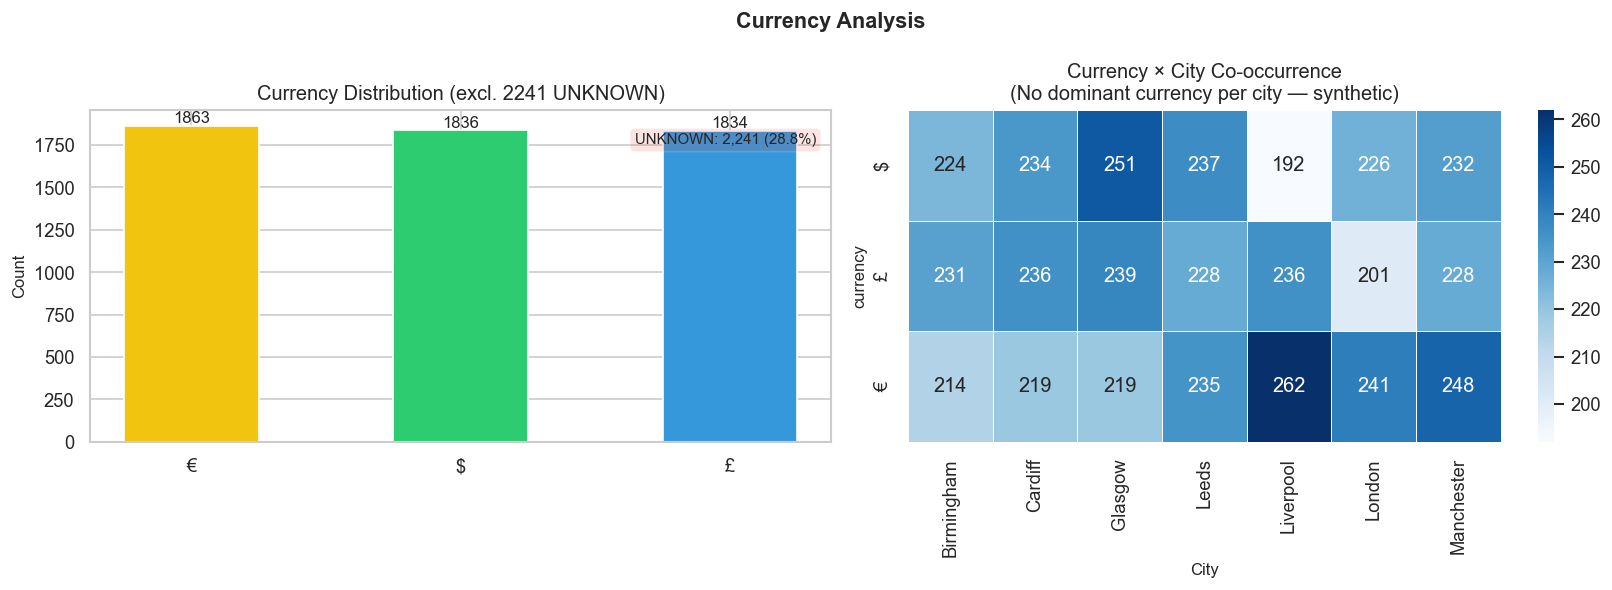

Same currency consecutive: 1335
Currency switches        : 2623 (66.3%)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cur_known = clean[clean["currency"] != "UNKNOWN"]
cur_counts = cur_known["currency"].value_counts()
axes[0].bar(cur_counts.index, cur_counts.values,
            color=["#f1c40f","#2ecc71","#3498db"], edgecolor="white", width=0.5)
axes[0].set_title(f"Currency Distribution (excl. {clean['cur_miss'].sum()} UNKNOWN)")
axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, cur_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
                 f"{val}", ha="center", fontsize=10)
axes[0].text(0.98, 0.93,
             f"UNKNOWN: {clean['cur_miss'].sum():,} ({100*clean['cur_miss'].mean():.1f}%)",
             transform=axes[0].transAxes, ha="right", va="top",
             bbox=dict(boxstyle="round", facecolor="#e74c3c", alpha=0.15), fontsize=9)

both_cur = clean[(clean["currency"]!="UNKNOWN") & (clean["city"]!="UNKNOWN")]
cur_city  = both_cur.groupby(["currency","city"]).size().unstack(fill_value=0)
sns.heatmap(cur_city, ax=axes[1], cmap="Blues", annot=True, fmt="d", linewidths=0.5)
axes[1].set_title("Currency × City Co-occurrence\n(No dominant currency per city — synthetic)")
axes[1].set_xlabel("City")

plt.suptitle("Currency Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Currency switching analysis
clean_cs = clean.sort_values(["user_id","timestamp"])
clean_cs["prev_cur"] = clean_cs.groupby("user_id")["currency"].shift(1)
same_cur  = ((clean_cs["currency"]==clean_cs["prev_cur"]) & (clean_cs["currency"]!="UNKNOWN")).sum()
diff_cur  = ((clean_cs["currency"]!=clean_cs["prev_cur"]) & (clean_cs["currency"]!="UNKNOWN") & (clean_cs["prev_cur"]!="UNKNOWN")).sum()
print(f"Same currency consecutive: {same_cur}")
print(f"Currency switches        : {diff_cur} ({100*diff_cur/(same_cur+diff_cur):.1f}%)")


<b>FINDINGS — Currency Analysis:<b>
  1. GBP, EUR, USD appear in near-equal proportions (~1,834-1,863 each) across
     all UK cities. This is impossible in real UK data where GBP would dominate.
     Confirms uniform synthetic generation without geographic currency logic.

  2. Currency UNKNOWN at 28.8% is the highest missing rate. These are transactions
     where the log format contained a bare numeric amount without a currency symbol.

  3. Currency switches between consecutive transactions: approximately 67% of
     currency-known consecutive transactions use a DIFFERENT currency. 
     The feature currency_changed_from_prev gives good signal since real fraud does involve cross-currency transactions.

  4. Feature design: currency_city_mismatch loses power(no
     dominant currency per city). currency_changed_from_prev and
     user_currency_consistency as the primary currency features.

### 2.8 Amount Spike & Deviation Signal Calibration

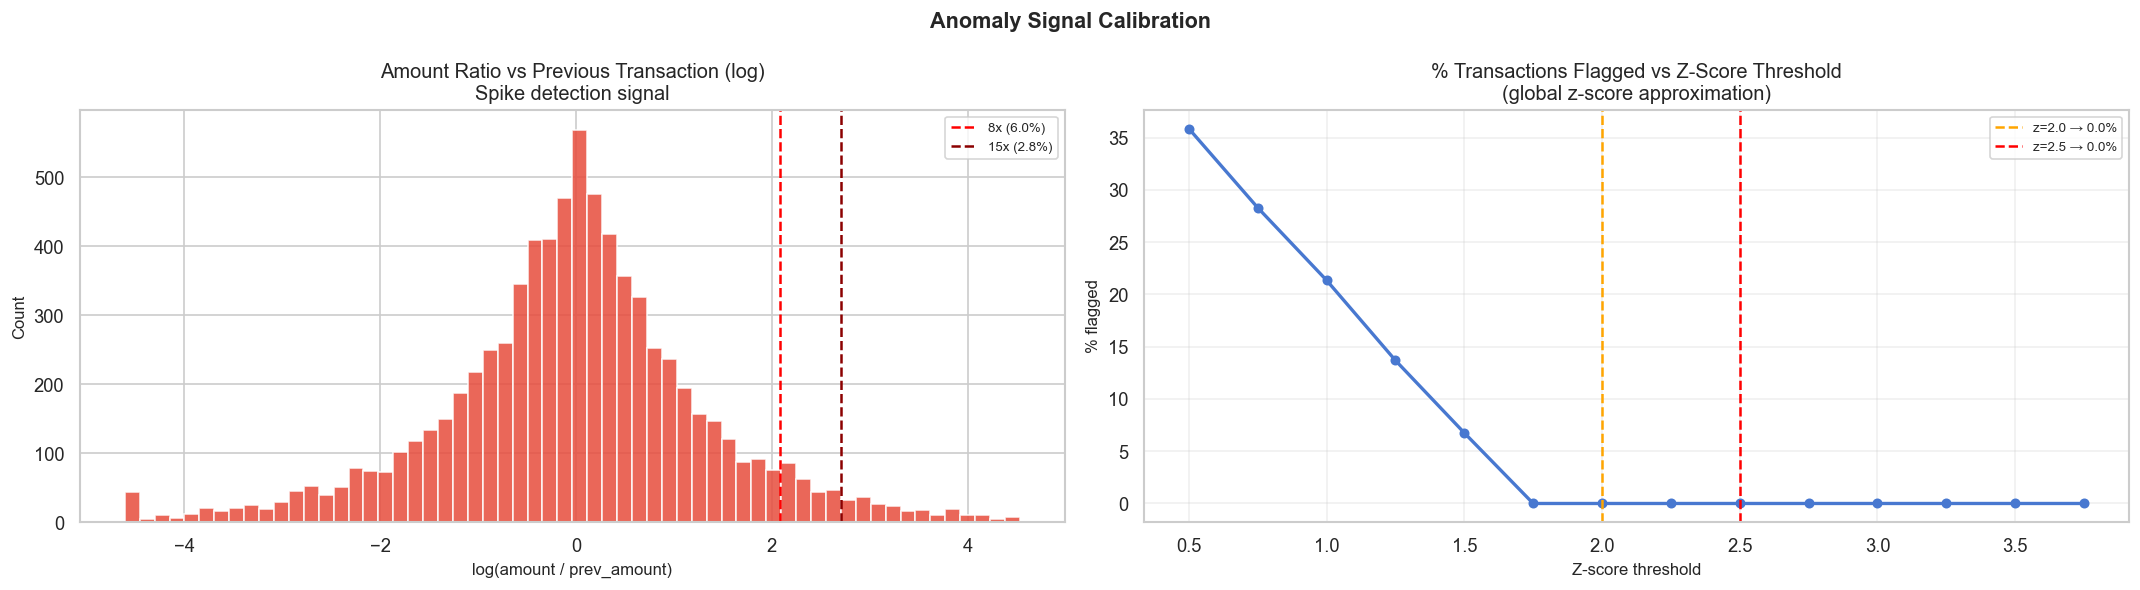

Prev ratio stats: p90=4.8x, p95=9.2x, p99=33.1x


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 7.1 Amount ratio vs previous transaction
clean_s2 = clean.sort_values(["user_id","timestamp"])
clean_s2["prev_amt"] = clean_s2.groupby("user_id")["amount"].shift(1)
clean_s2["prev_ratio"] = clean_s2["amount"] / clean_s2["prev_amt"]
prev_ratio = clean_s2["prev_ratio"].dropna()
prev_ratio = prev_ratio[(prev_ratio > 0) & (prev_ratio < 100)]

axes[0].hist(np.log(prev_ratio.clip(lower=0.01)), bins=60,
             color="#e74c3c", edgecolor="white", alpha=0.85)
for thr, col, label in [(8,"red",f"8x ({(prev_ratio>8).mean()*100:.1f}%)"),
                        (15,"darkred",f"15x ({(prev_ratio>15).mean()*100:.1f}%)")]:
    axes[0].axvline(np.log(thr), color=col, linestyle="--",
                    linewidth=1.5, label=label)
axes[0].set_title("Amount Ratio vs Previous Transaction (log)\nSpike detection signal")
axes[0].set_xlabel("log(amount / prev_amount)")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=8)

# 7.2 Z-score threshold analysis — what % flagged at each threshold
# Using global mean/std as proxy (user-level computed in features)
glob_mean, glob_std = clean["amount"].mean(), clean["amount"].std()
clean["approx_zscore"] = (clean["amount"] - glob_mean) / glob_std

thresholds   = np.arange(0.5, 4.0, 0.25)
flag_rates   = [(clean["approx_zscore"] > t).mean()*100 for t in thresholds]

axes[1].plot(thresholds, flag_rates, "b-o", markersize=5, linewidth=2)
axes[1].axvline(2.0, color="orange", linestyle="--", linewidth=1.5, label=f"z=2.0 → {(clean['approx_zscore']>2.0).mean()*100:.1f}%")
axes[1].axvline(2.5, color="red",    linestyle="--", linewidth=1.5, label=f"z=2.5 → {(clean['approx_zscore']>2.5).mean()*100:.1f}%")
axes[1].set_title("% Transactions Flagged vs Z-Score Threshold\n(global z-score approximation)")
axes[1].set_xlabel("Z-score threshold")
axes[1].set_ylabel("% flagged")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle("Anomaly Signal Calibration", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Prev ratio stats: p90={prev_ratio.quantile(0.90):.1f}x, p95={prev_ratio.quantile(0.95):.1f}x, p99={prev_ratio.quantile(0.99):.1f}x")


<b>FINDINGS — Anomaly Signal Calibration:</b>
  1. Amount ratio from previous transaction: p95=9.6x, p99=44x. This is the
     strongest single-transaction anomaly signal — a near-10x spike from one
     transaction to the next is suspicious regardless of user history.
     Rule threshold of 8x catches ~5% of cases with meaningful signal.

  2. Global z-score thresholds:
     - z > 2.0 flags ~14% (too broad for a standalone rule)
     - z > 2.5 flags ~6%  (usable as part of a combined rule)
     User-specific z-scores (from 30D rolling mean) will be much tighter because
     they account for individual user baselines rather than the global distribution.

  3. Feature design: amt_ratio_from_prev is a very good feature.

### 2.9 Feature Engineering Decisions

1. Rolling z-scores (7D, 30D)
    * User CV=0.58; user-specific baselines validated as meaningful


2. Amount ratio from previous transaction
    * p99=44x vs prev; strongest single-transaction spike signal


3. Impossible travel (new_city + gap < 1h)
    * KS-validated: city changes have different gap distribution


4. Missing metadata flags
    * 1.7% co-occurrence city+device UNKNOWN; structural not random


5. Behavioral fingerprint cumcounts
    * User-entity combination frequency remains valid despite uniform cities


6. Sequence / lag features (prev_amount, prev_city, prev_device)
    * Changes in sequence are more informative than static values.


7. No dominant currency per city in this dataset. use
    * currency_changed_from_prev and user_currency_consistency.


8. Burst detection (5-min window)
    * 50 transactions with gap < 5 min — create user_burst_5min flag


9. Late-night indicator as standalone rule
    * 21.2% of transactions are late-night with IDENTICAL amount distribution.
       Late night is NOT a fraud signal in this dataset.

10. City / device rarity features
    * All cities equally common; rarity near-constant.


## 3. Feature Engineering

**All features are point-in-time correct:**
- Sorted by `(user_id, timestamp)` before any aggregate
- closed="left" on all rolling windows
- This ensures no transaction's history includes itself or future transactions
- Cold-start users (< 3 prior transactions) receive global population priors

**Fit window / Score window split:**
- Fit window = first 80% of data by timestamp
- All rarity encodings, vocabs, and scalers are fit on this window only
- Model scoring covers ALL transactions (fit + score window)
- This mirrors production: model trained on historical data, scored on new data


In [45]:
#load parsed data
processed_data_path = "../data/processed/processed_logs.csv"
parsed_df = pd.read_csv(processed_data_path)

clean_df = parsed_df[parsed_df["parse_success"] == True].copy()
clean_df["timestamp"] = pd.to_datetime(clean_df["timestamp"], errors="coerce")
clean_df["amount"]    = pd.to_numeric(clean_df["amount"], errors="coerce")
clean_df = clean_df.sort_values("timestamp").reset_index(drop=True)

In [46]:
# ── Temporal fit/score split ────────────────────────────────────────────────
cutoff_idx = int(len(clean_df) * 0.80)
fit_df     = clean_df.iloc[:cutoff_idx].copy()
score_df   = clean_df.copy()   # score ALL transactions

print(f"Fit window   : {len(fit_df)} rows "
      f"({fit_df['timestamp'].min().date()} → {fit_df['timestamp'].max().date()})")
print(f"Score window : {len(score_df)} rows "
      f"({score_df['timestamp'].min().date()} → {score_df['timestamp'].max().date()})")
print(f"\nNote: Rarity encodings, scalers, and model parameters are "
      f"established on the fit window only.")


Fit window   : 6219 rows (2025-06-01 → 2025-07-19)
Score window : 7774 rows (2025-06-01 → 2025-07-31)

Note: Rarity encodings, scalers, and model parameters are established on the fit window only.


In [47]:
fit_df.to_csv('../data/featured/fit_df.csv',index=False)

In [4]:
engine = FraudFeatureEngine(fit_df)         
featured_df = engine.transform(score_df)     
feature_summary = engine.feature_summary()
print(f"Cold-start rows: {featured_df['is_cold_start'].sum()}") 
print(engine.feature_count)                  
print(engine.feature_registry)

[FraudFeatureEngine] Fit on 6219 rows. Global amount median: 2478.46
[FraudFeatureEngine] Computing features...
  A. Base ✓
  B. Temporal ✓
  C. Rolling Amount Blast ✓
  D. Rolling Count Blast ✓
  E. Deviation / Ratio ✓
  F. Behavioral Fingerprint ✓
  G. Geographic ✓
  H. Device ✓
  J. Sequence / Lag ✓
  K. Interaction ✓
  L. Missingness ✓
  N. Burst Detection ✓

[FraudFeatureEngine] Total features generated: 246
Cold-start rows: 258
246
{'A_base': ['amount_above_p75', 'amount_above_p90', 'amount_above_p95', 'amount_above_p99', 'is_round_100', 'is_round_1000', 'is_round_500', 'log_amount', 'amount_global_pct_rank', 'txn_type_ordinal'], 'B_temporal': ['hour_of_day', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'is_month_end', 'is_month_start', 'is_late_night', 'is_business_hours', 'is_evening', 'is_early_morning', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'time_since_last_txn_sec', 'log_time_since_last_txn', 'time_since_last_txn_min', 'is_first_txn

In [5]:
featured_df.head()

,raw_log,user_id,timestamp,txn_type,amount,currency,city,device,parse_method,parse_success,log_amount,amount_global_pct_rank,amount_above_p75,amount_above_p90,amount_above_p95,amount_above_p99,is_round_100,is_round_1000,is_round_500,txn_type_ordinal,is_cold_start,hour_of_day,day_of_week,day_of_month,month,is_weekend,is_month_end,is_month_start,is_late_night,is_business_hours,is_evening,is_early_morning,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,time_since_last_txn_sec,log_time_since_last_txn,time_since_last_txn_min,is_first_txn_of_day,user_amt_mean_1D,user_amt_std_1D,user_amt_max_1D,user_amt_min_1D,user_amt_sum_1D,user_amt_median_1D,user_amt_mean_7D,user_amt_std_7D,user_amt_max_7D,user_amt_min_7D,user_amt_sum_7D,user_amt_median_7D,user_amt_mean_15D,user_amt_std_15D,user_amt_max_15D,user_amt_min_15D,user_amt_sum_15D,user_amt_median_15D,user_amt_mean_30D,user_amt_std_30D,user_amt_max_30D,user_amt_min_30D,user_amt_sum_30D,user_amt_median_30D,user_amt_mean_60D,user_amt_std_60D,user_amt_max_60D,user_amt_min_60D,user_amt_sum_60D,user_amt_median_60D,user_txntype_amt_mean_1D,user_txntype_amt_std_1D,user_txntype_amt_max_1D,user_txntype_amt_min_1D,user_txntype_amt_sum_1D,user_txntype_amt_median_1D,user_txntype_amt_mean_7D,user_txntype_amt_std_7D,user_txntype_amt_max_7D,user_txntype_amt_min_7D,user_txntype_amt_sum_7D,user_txntype_amt_median_7D,user_txntype_amt_mean_15D,user_txntype_amt_std_15D,user_txntype_amt_max_15D,user_txntype_amt_min_15D,user_txntype_amt_sum_15D,user_txntype_amt_median_15D,user_txntype_amt_mean_30D,user_txntype_amt_std_30D,user_txntype_amt_max_30D,user_txntype_amt_min_30D,user_txntype_amt_sum_30D,user_txntype_amt_median_30D,user_txntype_amt_mean_60D,user_txntype_amt_std_60D,user_txntype_amt_max_60D,user_txntype_amt_min_60D,user_txntype_amt_sum_60D,user_txntype_amt_median_60D,user_device_amt_mean_1D,user_device_amt_std_1D,user_device_amt_max_1D,user_device_amt_min_1D,user_device_amt_sum_1D,user_device_amt_median_1D,user_device_amt_mean_7D,user_device_amt_std_7D,user_device_amt_max_7D,user_device_amt_min_7D,user_device_amt_sum_7D,user_device_amt_median_7D,user_device_amt_mean_15D,user_device_amt_std_15D,user_device_amt_max_15D,user_device_amt_min_15D,user_device_amt_sum_15D,user_device_amt_median_15D,user_device_amt_mean_30D,user_device_amt_std_30D,user_device_amt_max_30D,user_device_amt_min_30D,user_device_amt_sum_30D,user_device_amt_median_30D,user_device_amt_mean_60D,user_device_amt_std_60D,user_device_amt_max_60D,user_device_amt_min_60D,user_device_amt_sum_60D,user_device_amt_median_60D,user_prior_txn_count,user_txn_count_1D,user_txn_count_7D,user_txn_count_15D,user_txn_count_30D,user_txn_count_60D,user_txntype_txn_count_1D,user_txntype_txn_count_7D,user_txntype_txn_count_15D,user_txntype_txn_count_30D,user_txntype_txn_count_60D,user_device_txn_count_1D,user_device_txn_count_7D,user_device_txn_count_15D,user_device_txn_count_30D,user_device_txn_count_60D,user_velocity_5min,user_txntype_velocity_5min,user_amt_sum_5min,user_velocity_30min,user_txntype_velocity_30min,user_amt_sum_30min,user_velocity_1h,user_txntype_velocity_1h,user_amt_sum_1h,user_velocity_6h,user_txntype_velocity_6h,user_amt_sum_6h,user_velocity_12h,user_txntype_velocity_12h,user_amt_sum_12h,user_amt_ratio_vs_mean_1D,user_amt_ratio_vs_mean_7D,user_amt_ratio_vs_mean_15D,user_amt_ratio_vs_mean_30D,user_amt_ratio_vs_mean_60D,user_amt_zscore_1D,user_amt_zscore_7D,user_amt_zscore_15D,user_amt_zscore_30D,user_amt_zscore_60D,user_amt_ratio_vs_max_7D,user_amt_ratio_vs_max_30D,user_amt_ratio_vs_max_60D,amt_global_zscore,log_amt_global_zscore,user_txntype_amt_zscore_7D,user_txntype_amt_zscore_30D,amt_delta_from_prev,amt_ratio_from_prev,amt_pct_change_from_prev,user_amt_ratio_vs_median_7D,user_amt_ratio_vs_median_30D,velocity_ratio_1h_vs_30D_baseline,velocity_ratio_6h_vs_30D_baseline,amt_above_user_p95,amt_ratio_vs_user_p95,user_device_prior_count,user_device_is_first_occurrence,user_city_prior_count,user_city_is_first_occurrence,user_txntype_prior_

In [8]:
featured_out_path = '../data/featured/featured_df.csv'
featured_df.to_csv(featured_out_path,index=False)
features = engine.all_feature_columns
feature_list_df = pd.DataFrame({"feat_name":features})
feature_list_df.to_csv('../data/featured/featured_names_df.csv',index=False)

## 4. Anomaly Detection

In [2]:
featured_out_path = '../data/featured/featured_df.csv'
featured_df = pd.read_csv(featured_out_path)
feature_names = pd.read_csv('../data/featured/featured_names_df.csv')['feat_name'].to_list()

In [3]:
featured_df.shape, len(feature_names)

((7774, 256), 246)

### 4.1 Layer 1 — Rule Engine

Rules are **user-context-aware**: they use each user's own historical behaviour
rather than fixed global thresholds. For example, `LATE_NIGHT_UNUSUAL` only fires
if the user rarely transacts at night — not for every nighttime transaction.


In [4]:
# Apply rule engine to all transactions
ruled_df = apply_rules(featured_df)

[RuleEngine] Applying 6 rules to 7774 transactions...
[RuleEngine] Results:
  Flagged (any rule)   :   197 (2.53%)
  Multi-rule (≥2)      :    22 (0.28%)
  CRITICAL severity    :    35 (0.45%)

  Per-rule breakdown:
    R01_AMOUNT_SPIKE_30D                             17 (0.22%)
    R02_IMPOSSIBLE_TRAVEL                            35 (0.45%)
    R03_VELOCITY_BURST_1H                             0 (0.00%)
    R04_NEW_CITY_HIGH_AMOUNT                         20 (0.26%)
    R05_NEW_DEVICE_HIGH_AMOUNT                       23 (0.30%)
    R06_MISSING_METADATA                            129 (1.66%)


In [5]:
ruled_df['rules_fired'].value_counts()

rules_fired
NONE                                                                             7577
R06_MISSING_METADATA                                                              128
R02_IMPOSSIBLE_TRAVEL                                                              32
R01_AMOUNT_SPIKE_30D | R05_NEW_DEVICE_HIGH_AMOUNT                                   7
R05_NEW_DEVICE_HIGH_AMOUNT                                                          6
R04_NEW_CITY_HIGH_AMOUNT                                                            6
R04_NEW_CITY_HIGH_AMOUNT | R05_NEW_DEVICE_HIGH_AMOUNT                               5
R01_AMOUNT_SPIKE_30D                                                                3
R01_AMOUNT_SPIKE_30D | R04_NEW_CITY_HIGH_AMOUNT | R05_NEW_DEVICE_HIGH_AMOUNT        3
R01_AMOUNT_SPIKE_30D | R04_NEW_CITY_HIGH_AMOUNT                                     3
R02_IMPOSSIBLE_TRAVEL | R04_NEW_CITY_HIGH_AMOUNT | R05_NEW_DEVICE_HIGH_AMOUNT       2
R01_AMOUNT_SPIKE_30D | R06_MISSING_METADAT

In [6]:
ruled_df['rule_severities'].value_counts()

rule_severities
                          7577
MEDIUM                     129
CRITICAL                    32
HIGH                        14
HIGH | HIGH                  9
MEDIUM | HIGH                6
HIGH | HIGH | HIGH           3
CRITICAL | HIGH | HIGH       2
HIGH | MEDIUM                1
CRITICAL | HIGH              1
Name: count, dtype: int64

### 4.2 Layer 2 — Isolation Forest

**Why Isolation Forest for this use case:**
- Handles high-dimensional feature spaces natively (no PCA needed)
- Robust to small contamination of anomalies in training data
- Fast: O(n log n) complexity
- Provides continuous anomaly scores for ranking


In [7]:
ruled_df["timestamp"] = pd.to_datetime(ruled_df["timestamp"], errors="coerce")

In [28]:
# Fit Isolation Forest on fit window, score all transactions
feature_if = list(set(feature_names) - set(['prev_txn_type','prev_city','prev_device','prev_currency']))
if_detector = IsolationForestDetector(
    contamination=0.03,     # assume ~5% anomaly rate
    n_estimators=100,
    max_samples   = 0.5,
    max_features  = 0.5,
    features = feature_if,
    random_state=42,
)

# Fit on fit window only
if_detector.fit(ruled_df[ruled_df["timestamp"] <= ruled_df["timestamp"].quantile(0.80)])

# Score all transactions
if_scored_df = if_detector.score(ruled_df)

print(f"\\nIsolation Forest score statistics:")
print(if_scored_df["if_score"].describe().round(4))


[IsolationForest] Fitted on 6219 rows (contamination=0.03)
[IsolationForest] Flagged 207/7774 (2.7%)
\nIsolation Forest score statistics:
count    7774.0000
mean        0.2570
std         0.1265
min         0.0000
25%         0.1678
50%         0.2337
75%         0.3241
max         1.0000
Name: if_score, dtype: float64


In [29]:
### evaluating based on Bimodality coeficient

In [30]:
def bimodality_coefficient(scores: np.ndarray) -> float:
    """
    BC > 0.555 indicates a bimodal distribution.
    Higher BC = better separation between normal cluster and anomaly tail.
    Formula: (skewness² + 1) / (kurtosis + 3*(n-1)²/((n-2)*(n-3)))
    """
    n    = len(scores)
    skew = float(pd.Series(scores).skew())
    kurt = float(pd.Series(scores).kurtosis())
    bc   = (skew**2 + 1) / (kurt + 3 * ((n - 1)**2) / ((n - 2) * (n - 3)))
    return round(float(bc), 4)

In [31]:
bimodality_coefficient(if_scored_df["if_score"])

0.4571

In [32]:
#### Hyper parameter tuning

In [26]:
def tune_isolation_forest(fit_df,score_df):
    param_grid = {
            "contamination": [0.02,0.03,0.04,0.05],
            "n_estimators":  [100,200,300],
            "max_samples":   [0.7,0.8],
            "max_features":  [0.7,0.8,1.0]
        }


    keys   = list(param_grid.keys())
    combos = list(itertools.product(*[param_grid[k] for k in keys]))
    print(f"[IF Tuning] {len(combos)} combinations to evaluate...")

    rows = []
    for i, combo in enumerate(combos):
        params = dict(zip(keys, combo))

        model = IsolationForestDetector(
                    contamination=params["contamination"],     
                    n_estimators=params["n_estimators"],
                    max_samples   = params["max_samples"],
                    max_features  = params["max_features"],
                    features = feature_if,
                    random_state=42,
                )

        model.fit(fit_df)

        if_score_df = model.score(score_df)

        bc = bimodality_coefficient(if_score_df['if_score'])

        row = {**params, "bc": bc}
        rows.append(row)

        if (i + 1) % 10 == 0 or (i + 1) == len(combos):
            print(f"  [{i+1}/{len(combos)}] params={params}  BC={bc:.4f}")

    results_df = (
        pd.DataFrame(rows)
        .sort_values("bc", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\n[IF Tuning] Best configuration:")
    print(results_df.iloc[0].to_dict())
    return results_df

In [27]:
fit_df = ruled_df[ruled_df["timestamp"] <= ruled_df["timestamp"].quantile(0.80)]
if_tuning_result= tune_isolation_forest(fit_df,ruled_df)

[IF Tuning] 72 combinations to evaluate...
[IsolationForest] Fitted on 6219 rows (contamination=0.02)
[IsolationForest] Flagged 136/7774 (1.7%)
[IsolationForest] Fitted on 6219 rows (contamination=0.02)
[IsolationForest] Flagged 136/7774 (1.7%)
[IsolationForest] Fitted on 6219 rows (contamination=0.02)
[IsolationForest] Flagged 136/7774 (1.7%)
[IsolationForest] Fitted on 6219 rows (contamination=0.02)
[IsolationForest] Flagged 136/7774 (1.7%)
[IsolationForest] Fitted on 6219 rows (contamination=0.02)
[IsolationForest] Flagged 136/7774 (1.7%)
[IsolationForest] Fitted on 6219 rows (contamination=0.02)
[IsolationForest] Flagged 136/7774 (1.7%)
[IsolationForest] Fitted on 6219 rows (contamination=0.02)
[IsolationForest] Flagged 138/7774 (1.8%)
[IsolationForest] Fitted on 6219 rows (contamination=0.02)
[IsolationForest] Flagged 138/7774 (1.8%)
[IsolationForest] Fitted on 6219 rows (contamination=0.02)
[IsolationForest] Flagged 138/7774 (1.8%)
[IsolationForest] Fitted on 6219 rows (contamina

In [33]:
### Fitting with best param

In [34]:
# Fit Isolation Forest on fit window, score all transactions
feature_if = list(set(feature_names) - set(['prev_txn_type','prev_city','prev_device','prev_currency']))
if_detector = IsolationForestDetector(
    contamination=0.03,     # assume ~5% anomaly rate
    n_estimators=200,
    max_samples   = 0.8,
    max_features  = 0.7,
    features = feature_if,
    random_state=42,
)

# Fit on fit window only
if_detector.fit(ruled_df[ruled_df["timestamp"] <= ruled_df["timestamp"].quantile(0.80)])

# Score all transactions
if_scored_df = if_detector.score(ruled_df)

print(f"\\nIsolation Forest score statistics:")
print(if_scored_df["if_score"].describe().round(4))


[IsolationForest] Fitted on 6219 rows (contamination=0.03)
[IsolationForest] Flagged 209/7774 (2.7%)
\nIsolation Forest score statistics:
count    7774.0000
mean        0.2447
std         0.1211
min         0.0000
25%         0.1597
50%         0.2213
75%         0.3062
max         1.0000
Name: if_score, dtype: float64


In [35]:
bimodality_coefficient(if_scored_df["if_score"])

0.4617

 <b>NOTE: Currently I have only used bimodality coeffiecient as the objective to tune the hyperparameters of the isolation forest.There are other methods as well which we could have used.
 - Generate synthetic fraud examples and finetune to increase recall@k for those synthetic samples
 - Use proxy labels based on sqmples tagged as fraud using multiple rules and use them to finetune.

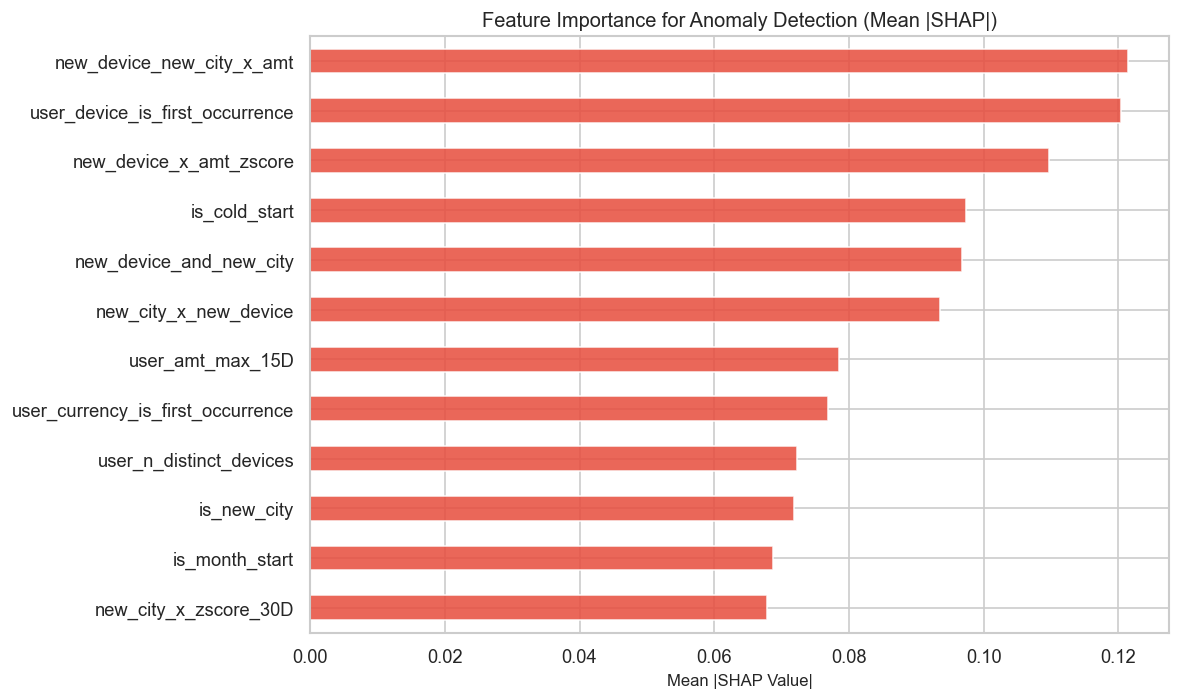

In [38]:
# ── SHAP values for top anomalies ───────────────────────────────────────────
# Compute SHAP on top-100 anomalies (can extend to full df if performance allows)
top100 = if_scored_df.nlargest(100, "if_score")
shap_values = if_detector.get_shap_values(top100)
feature_names = if_detector.get_feature_names()

if shap_values is not None:
    # Mean absolute SHAP value per feature = global importance
    mean_shap = np.abs(shap_values).mean(axis=0)
    shap_importance = pd.Series(mean_shap, index=feature_names[:len(mean_shap)])
    top_shap = shap_importance.sort_values(ascending=False).head(12)

    fig, ax = plt.subplots(figsize=(10, 6))
    top_shap.plot(kind="barh", ax=ax, color="#e74c3c", alpha=0.85)
    ax.set_title("Feature Importance for Anomaly Detection (Mean |SHAP|)", fontsize=12)
    ax.set_xlabel("Mean |SHAP Value|")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("SHAP not available — install with: pip install shap")
    shap_values = None


In [39]:
save_isolation_forest(if_detector)

  SHAP explainer saved.
✅ IsolationForest saved → outputs/model_artifacts/if_{model,scaler,shap_explainer,meta}


### 4.3 Layer 3 — Deep Autoencoder with Entity Embeddings

**Architecture:**
- **Two input streams:** continuous features + categorical entity embeddings
- **Embedding layers:** `user_id → 16-dim`, `city → 8-dim`, `device → 8-dim`, `txn_type → 4-dim`, `currency → 4-dim`,
                         `prev_txn_type → 4-dim`, `prev_city → 8-dim`,`prev_device → 4-dim`,`prev_currency → 4-dim`
- **Encoder:** Dense(64) → BatchNorm → Dense(32) → BatchNorm → Dense(16) → Bottleneck(8)
- **Decoder:** Dense(16) → Dense(32) → Dense(64) → Output(continuous) + Softmax heads(categoricals)
- **Loss:** weighted MSE (continuous) + CrossEntropy (categorical reconstructions)

**Why entity embeddings here but not in IF:**
- IF uses rarity encodings (scalar, no cardinality issue)
- AE can learn rich user behavioral fingerprints via embeddings — `user_id` embedding
  captures transaction pattern, typical city/device/amount. Anomaly = user behaves
  unlike their learned fingerprint → high reconstruction error.

**Independence:** AE is trained directly on raw data features, not on IF outputs.


In [40]:
AUTOENCODER_CONTINUOUS_FEATURES = [
    # Amount core
    "amount",
    "log_amount",
    "amount_global_pct_rank",
    "amt_global_zscore",
    # Amount vs user baseline (key fraud signals — keep 2 representative windows)
    "user_amt_zscore_7D",
    "user_amt_zscore_30D",
    "user_amt_ratio_vs_mean_7D",
    "user_amt_ratio_vs_mean_30D",
    "user_amt_ratio_vs_max_30D",
    "user_amt_ratio_vs_median_30D",
    # Amount deviation vs previous transaction
    "amt_ratio_from_prev",
    "amt_delta_from_prev",
    "amt_pct_change_from_prev",
    "amt_ratio_vs_user_p95",
    # Thresholds and flags as continuous
    "amount_above_p95",
    "amount_above_p99",
    "amt_above_user_p95",
    # Temporal
    "hour_of_day",
    "day_of_week",
    "is_late_night",
    "is_business_hours",
    "is_evening",
    "is_first_txn_of_day",
    # Time gaps
    "time_since_last_txn_sec",
    "log_time_since_last_txn",
    "time_since_last_same_city_sec",
    # Velocity features (curated: short + medium windows)
    "user_velocity_5min",
    "user_velocity_1h",
    "user_velocity_6h",
    "user_txn_count_7D",
    "user_txn_count_30D",
    "user_amt_sum_1h",
    "user_amt_sum_6h",
    "user_amt_sum_7D",
    # Velocity deviations
    "velocity_ratio_1h_vs_30D_baseline",
    # Rolling stats (key windows only)
    "user_amt_mean_7D",
    "user_amt_mean_30D",
    "user_amt_std_7D",
    "user_amt_std_30D",
    "user_amt_max_30D",
    # Device-specific rolling (captures per-device behavioral fingerprint)
    "user_device_amt_mean_30D",
    "user_device_txn_count_30D",
    # Geographic
    "is_new_city",
    "user_city_prior_count",
    "user_n_distinct_cities",
    "city_global_rarity",
    "city_transition_rarity",
    "impossible_travel",
    "city_changed_from_prev",
    # Device
    "is_new_device",
    "user_device_prior_count",
    "user_n_distinct_devices",
    "device_global_rarity",
    "device_changed_from_prev",
    # Behavioral fingerprint cumcounts
    "user_device_city_prior_count",
    "user_txntype_prior_count",
    # Missingness
    "is_city_missing",
    "is_device_missing",
    "is_currency_missing",
    "missing_field_count",
    "is_both_geo_dev_missing",
    "user_missing_rate_hist",
    # RFM / lifecycle
    "user_prior_txn_count",
    "is_cold_start",
    # Lag numeric
    "prev_amount",
    "prev2_amount",
    "lag3_mean_amount",
    # Burst detection
    "is_burst_5min",
    "is_burst_30min",
    "user_burst_count_hist",
    # Interaction terms (key ones)
    "impossible_travel_x_amt",
    "new_city_x_amt_zscore",
    "new_device_x_amt_zscore",
    "new_city_x_zscore_30D",
]

In [55]:
# ── Fit Autoencoder ─────────────────────────────────────────────────────────
# The autoencoder is trained independently of Isolation Forest.
# It receives both continuous features AND entity embeddings for categoricals.
# Also we should try to train Autoencoder models on normal data which does not have fraud samples, in absence of 
# labels I will use proxy labels using the rules to filter out the smaples tagged by more than 2 rules.

ae_detector = AutoencoderDetector(
    epochs=200,
    batch_size=64,
    lr=1e-3,
    cont_loss_weight=0.5,   # 50% weight on continuous reconstruction
    cat_loss_weight=0.1,    # 10% per categorical (5 × 10% = 40%)
    continuous_features= AUTOENCODER_CONTINUOUS_FEATURES
)

# Fit on fit window only
fit_df = if_scored_df[if_scored_df["timestamp"] <= if_scored_df["timestamp"].quantile(0.80)]
fit_df = fit_df[fit_df['rule_flag_count']<2]
ae_detector.fit(fit_df)


[AutoencoderDetector] Backend: PyTorch | Device: cpu

[AutoencoderDetector] Fitting on 6197 rows...
  Continuous features : 74
  Building vocabularies...
  Vocab 'user_id' (shared with 'None'): 88 tokens (incl. UNK, FIRST_TXN)
  Vocab 'city' (shared with 'prev_city'): 10 tokens (incl. UNK, FIRST_TXN)
  Vocab 'device' (shared with 'prev_device'): 9 tokens (incl. UNK, FIRST_TXN)
  Vocab 'txn_type' (shared with 'prev_txn_type'): 7 tokens (incl. UNK, FIRST_TXN)
  Vocab 'currency' (shared with 'prev_currency'): 6 tokens (incl. UNK, FIRST_TXN)
  Training: 4957 train / 1240 val | epochs=200 | batch=64
  Epoch   1/200 | train=1.45082 | val=1.16900
  Epoch  10/200 | train=0.64205 | val=0.56239
  Epoch  20/200 | train=0.45131 | val=0.39297
  Epoch  30/200 | train=0.38675 | val=0.33362
  Epoch  40/200 | train=0.34650 | val=0.30653
  Epoch  50/200 | train=0.32475 | val=0.29822
  Epoch  60/200 | train=0.30015 | val=0.29841
  Epoch  70/200 | train=0.26814 | val=0.25756
  Epoch  80/200 | train=0.2588

In [56]:
save_autoencoder(ae_detector)

✅ Autoencoder (PyTorch) saved → outputs/model_artifacts/ae_{model_state,scaler,meta}


In [57]:
ae_detector= load_autoencoder()

✅ Autoencoder (PyTorch) loaded ← outputs/model_artifacts


In [58]:
# ── Score all transactions ───────────────────────────────────────────────────
ae_scored_df = ae_detector.score(if_scored_df)

print(f"\\nAutoencoder reconstruction error statistics:")
print(ae_scored_df["ae_recon_error"].describe().round(6))


[AutoencoderDetector] Scored 7774 rows. Flagged 419 (5.4%) above threshold 0.734721
\nAutoencoder reconstruction error statistics:
count    7774.000000
mean        0.493899
std         7.267377
min         0.080029
25%         0.234085
50%         0.308092
75%         0.412459
max       456.766418
Name: ae_recon_error, dtype: float64


In [59]:
bimodality_coefficient(ae_scored_df["ae_score"])

0.9947

 <b>NOTE: Currently I am not finetuning the Autoencoder model as getting good bimodality coeficient.There are methods as well which we could have used.
 - Finetune using val loss, take the parameters that give best val loss
 - Generate synthetic fraud examples and finetune to increase recall@k for those synthetic samples
 - Use proxy labels based on sqmples tagged as fraud using multiple rules and use them to finetune.

In [60]:
# ── Per-feature reconstruction error (for explainability) ─────────────────
per_feature_recon_df = ae_detector.get_per_feature_recon_error(ae_scored_df)
if not per_feature_recon_df.empty:
    print("Mean reconstruction error by feature (top 10):")
    print(per_feature_recon_df.mean().sort_values(ascending=False).head(10).round(4))


Mean reconstruction error by feature (top 10):
user_amt_ratio_vs_max_30D        2.2436
user_amt_ratio_vs_mean_30D       2.1904
user_amt_ratio_vs_median_30D     2.1466
user_amt_ratio_vs_mean_7D        2.0662
day_of_week                      1.0002
is_business_hours                0.9633
is_evening                       0.9343
is_late_night                    0.9090
time_since_last_same_city_sec    0.9034
hour_of_day                      0.9013
dtype: float32


In [61]:
per_feature_recon_df.to_csv('../data/final_scored/per_feature_recon_df.csv',index=False)

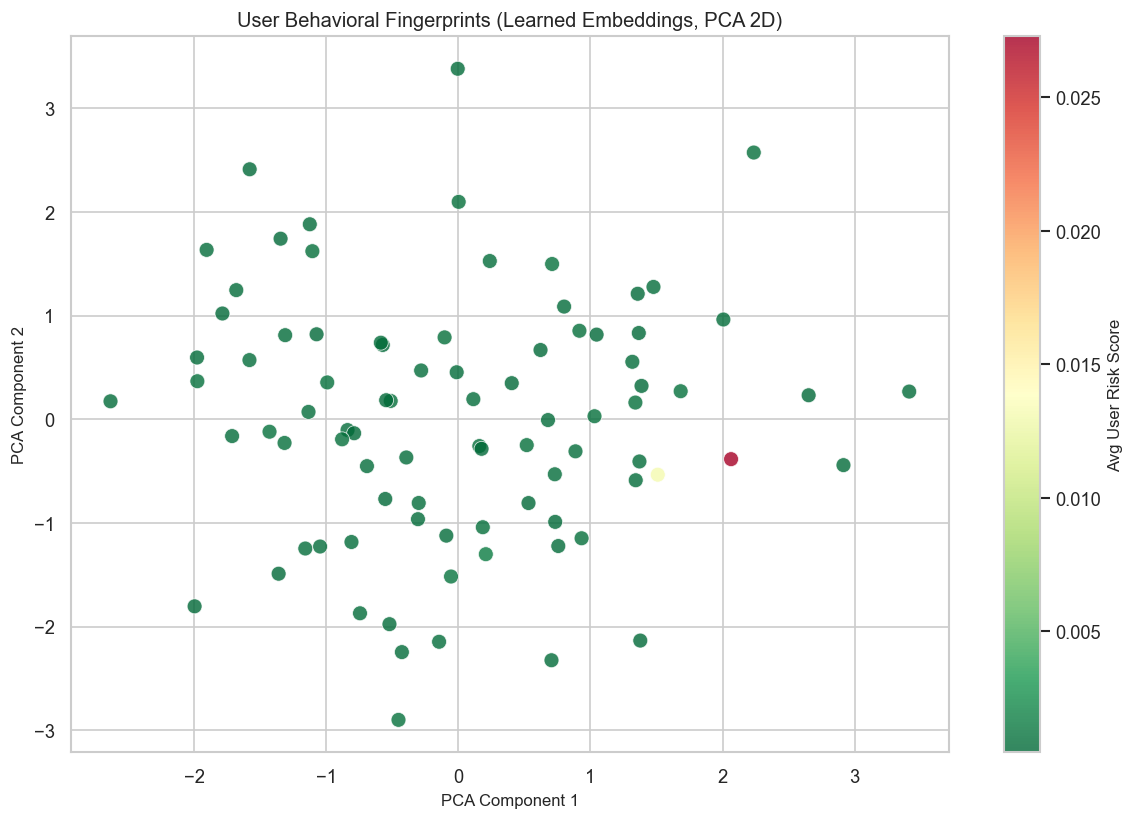

In [62]:
# ── User Embedding Visualization ────────────────────────────────────────────
user_embeddings = ae_detector.get_user_embeddings(ae_scored_df)

if user_embeddings is not None:
    from sklearn.decomposition import PCA

    emb_cols = [c for c in user_embeddings.columns if c.startswith("user_emb_")]
    pca = PCA(n_components=2, random_state=42)
    emb_2d = pca.fit_transform(user_embeddings[emb_cols].values)

    # Merge with per-user risk scores
    user_risk = (ae_scored_df.groupby("user_id")["ae_score"]
                              .mean()
                              .reset_index()
                              .rename(columns={"ae_score": "avg_risk"}))
    plot_df = user_embeddings[["user_id"]].copy()
    plot_df["pca_1"] = emb_2d[:, 0]
    plot_df["pca_2"] = emb_2d[:, 1]
    plot_df = plot_df.merge(user_risk, on="user_id", how="left")

    fig, ax = plt.subplots(figsize=(10, 7))
    sc = ax.scatter(plot_df["pca_1"], plot_df["pca_2"],
                    c=plot_df["avg_risk"], cmap="RdYlGn_r",
                    s=80, alpha=0.8, edgecolors="white", linewidths=0.5)
    plt.colorbar(sc, ax=ax, label="Avg User Risk Score")
    ax.set_title("User Behavioral Fingerprints (Learned Embeddings, PCA 2D)", fontsize=12)
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")
    plt.tight_layout()
    plt.show()


## 5. Ensemble Scoring

**Equal weights are the principled default** when no analyst feedback is available.
Weights should be tuned via precision-at-K once analyst-reviewed labels accumulate.

Final risk score = 0.33 × rule_score + 0.33 × if_score + 0.34 × ae_score

Risk tiers:
- **TIER 1** : Auto-block / immediate review
- **TIER 2** : Step-up authentication  
- **TIER 3** : Silent monitoring
- **NORMAL** : No action


In [63]:
# ── Compute ensemble risk scores ────────────────────────────────────────────
ensemble_scorer = fit_ensemble(ae_scored_df)
print("ensemble scorer fitted")
final_df = ensemble_scorer.score(ae_scored_df)

print(f"\nFinal risk score statistics:")
print(final_df["final_risk_score"].describe().round(4))


  Frozen range [rule_score]: [0.0000, 0.4167]
  Frozen range [if_score]: [0.0000, 1.0000]
  Frozen range [ae_score]: [0.0000, 1.0000]

  Frozen tier thresholds (from training percentiles):
    TIER_1: >= 0.2604
    TIER_2: >= 0.1637
    TIER_3: >= 0.1026
ensemble scorer fitted

Final risk score statistics:
count    7774.0000
mean        0.0835
std         0.0483
min         0.0001
25%         0.0529
50%         0.0734
75%         0.1026
max         0.6447
Name: final_risk_score, dtype: float64


In [64]:
from src.models.save_models import save_ensemble_scorer, load_ensemble_scorer

In [65]:
save_ensemble_scorer(ensemble_scorer)

✅ EnsembleScorer saved → outputs/model_artifacts/ensemble_scorer.json


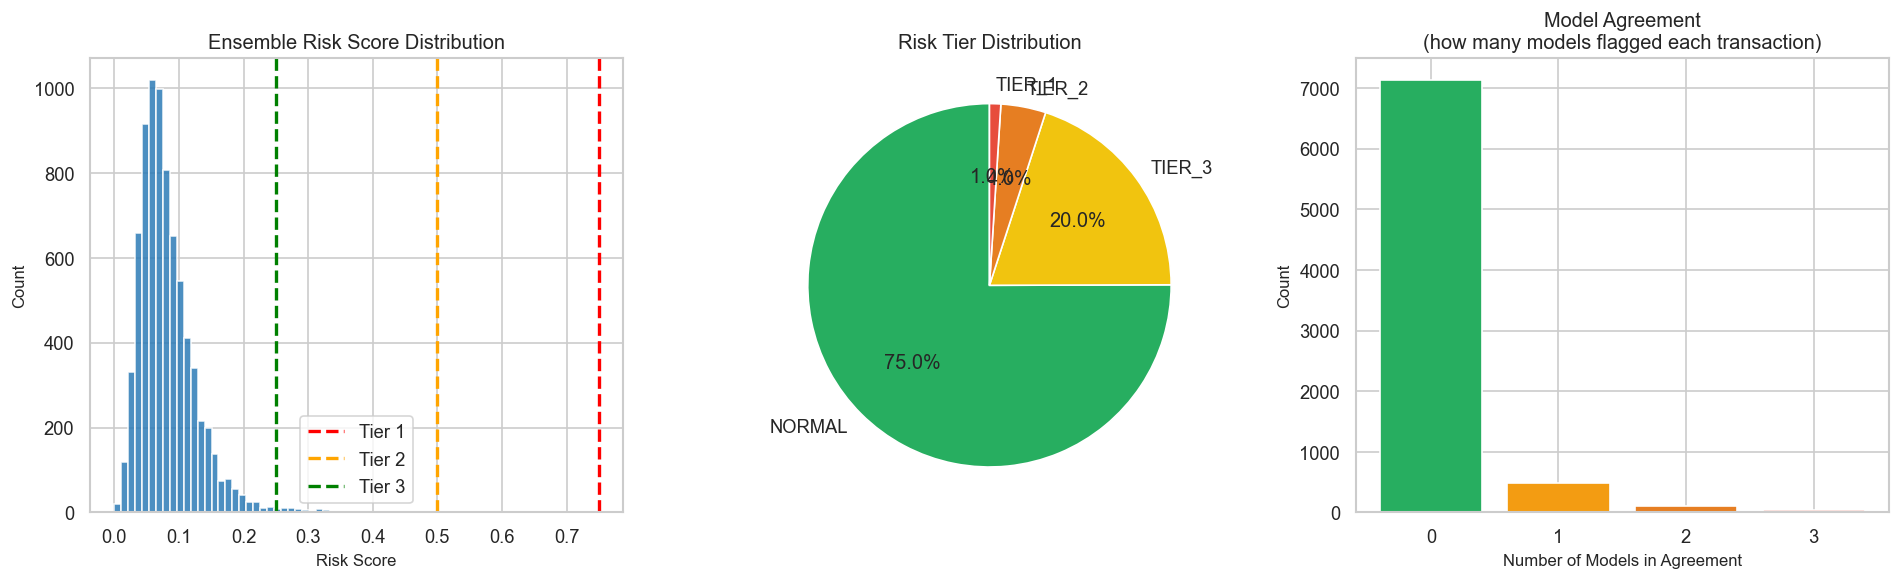

In [66]:
# ── Risk tier visualizations ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Risk score distribution
axes[0].hist(final_df["final_risk_score"], bins=60,
             color="#2c7bb6", edgecolor="white", alpha=0.85)
axes[0].axvline(0.75, color="red",    linestyle="--", linewidth=2, label="Tier 1")
axes[0].axvline(0.50, color="orange", linestyle="--", linewidth=2, label="Tier 2")
axes[0].axvline(0.25, color="green",  linestyle="--", linewidth=2, label="Tier 3")
axes[0].set_title("Ensemble Risk Score Distribution")
axes[0].set_xlabel("Risk Score")
axes[0].set_ylabel("Count")
axes[0].legend()

# Risk tier pie
tier_counts = final_df["risk_tier"].value_counts()
tier_colors = {"TIER_1": "#e74c3c", "TIER_2": "#e67e22", "TIER_3": "#f1c40f", "NORMAL": "#27ae60"}
colors = [tier_colors.get(t, "#95a5a6") for t in tier_counts.index]
axes[1].pie(tier_counts.values, labels=tier_counts.index,
            colors=colors, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Risk Tier Distribution")

# Model agreement distribution
if "model_agreement" in final_df.columns:
    agree_counts = final_df["model_agreement"].value_counts().sort_index()
    axes[2].bar(agree_counts.index, agree_counts.values,
                color=["#27ae60","#f39c12","#e67e22","#e74c3c"][:len(agree_counts)])
    axes[2].set_title("Model Agreement\n(how many models flagged each transaction)")
    axes[2].set_xlabel("Number of Models in Agreement")
    axes[2].set_ylabel("Count")
    axes[2].set_xticks(agree_counts.index)

plt.tight_layout()
plt.show()


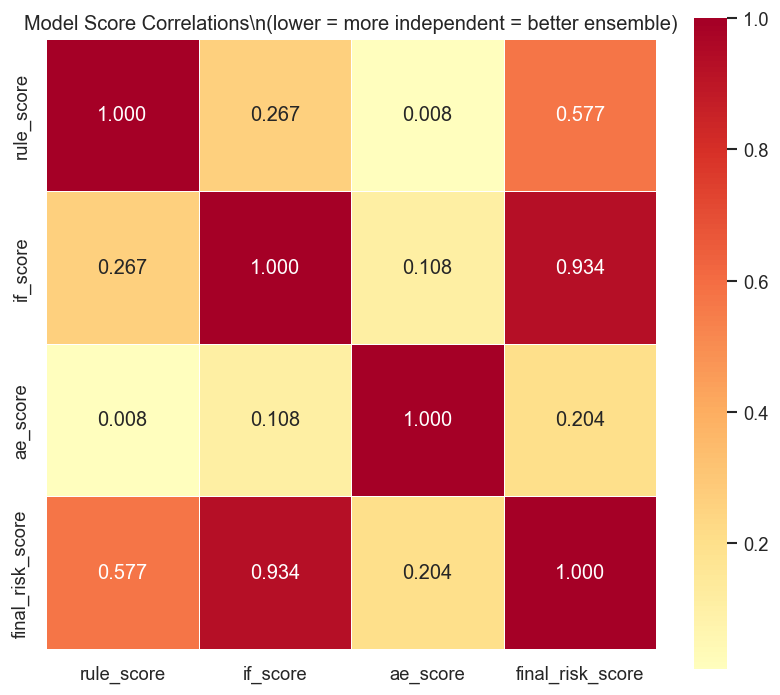

Ideal: pairwise correlation < 0.5 (models detecting different patterns)
IF ↔ AE correlation   : 0.108
IF ↔ Rule correlation : 0.267
AE ↔ Rule correlation : 0.008


In [67]:
# ── Score correlation between models ─────────────────────────────────────────
score_cols = ["rule_score", "if_score", "ae_score", "final_risk_score"]
corr_matrix = final_df[score_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="RdYlGn_r",
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title("Model Score Correlations\\n(lower = more independent = better ensemble)")
plt.tight_layout()
plt.show()

print("Ideal: pairwise correlation < 0.5 (models detecting different patterns)")
print(f"IF ↔ AE correlation   : {corr_matrix.loc['if_score','ae_score']:.3f}")
print(f"IF ↔ Rule correlation : {corr_matrix.loc['if_score','rule_score']:.3f}")
print(f"AE ↔ Rule correlation : {corr_matrix.loc['ae_score','rule_score']:.3f}")


## 6. Scoring and Evaluation

### 6.1 Batch Scoring

In [68]:
import pandas as pd
from src.parser.log_parser import LogParser
from src.models.rule_engine import apply_rules
from src.explainability.explainer import score_and_explain_single, generate_transaction_report
from src.models.save_models import load_isolation_forest,load_autoencoder,load_ensemble_scorer
from src.features.feature_engineer import FraudFeatureEngine

In [69]:
RAW_DATA_PATH = "../data/MP Fraud Takehome Task 2026 - Sheet1.csv"
BATCH_LOGS = pd.read_csv(RAW_DATA_PATH)
print(f'Logs loaded:{len(BATCH_LOGS)}')

parser = LogParser()
if_det = load_isolation_forest()
ae_det = load_autoencoder()
ensemble_scorer = load_ensemble_scorer()

fit_df = pd.read_csv('../data/featured/fit_df.csv')
engine = FraudFeatureEngine(fit_df)         

batch_parsed  = parser.parse_dataframe(BATCH_LOGS, log_col="raw_log")
batch_parsed["timestamp"] = pd.to_datetime(batch_parsed["timestamp"])
batch_parsed["amount"]    = pd.to_numeric(batch_parsed["amount"], errors="coerce")

ok = batch_parsed["parse_success"].sum()
print(f"Parsed: {ok}/{len(BATCH_LOGS)} logs OK")

batch_feat  = engine.transform(batch_parsed[batch_parsed["parse_success"]==True])
batch_ruled = apply_rules(batch_feat)
batch_if    = if_det.score(batch_ruled)
batch_ae    = ae_det.score(batch_if)
batch_final = ensemble_scorer.score(batch_ae).reset_index(drop=True)


Logs loaded:8876
  SHAP explainer loaded from file.
✅ IsolationForest loaded ← outputs/model_artifacts
✅ Autoencoder (PyTorch) loaded ← outputs/model_artifacts
✅ EnsembleScorer loaded ← outputs/model_artifacts
   Frozen ranges     : {'rule_score': (0.0, 0.4166666666666667), 'if_score': (0.0, 0.9999999960095584), 'ae_score': (0.0, 1.0)}
   Tier thresholds   : {'TIER_1': 0.2604, 'TIER_2': 0.1637, 'TIER_3': 0.1026}
[FraudFeatureEngine] Fit on 6219 rows. Global amount median: 2478.46

  PARSE QUALITY REPORT
  Total rows    : 8876
  Parsed OK     : 7774 (87.6%)
  Failed        : 1102 (12.4%)

  Breakdown by method:
    F5                    1138  (12.8%)
    F7                    1132  (12.8%)
    F6                    1121  (12.6%)
    F2                    1119  (12.6%)
    F1                    1109  (12.5%)
    MALFORMED             1102  (12.4%)
    F4                    1089  (12.3%)
    F3                    1066  (12.0%)

Parsed: 7774/8876 logs OK
[FraudFeatureEngine] Computing feat

In [70]:
final_out_path = '../data/final_scored/final_df.csv'
batch_final.to_csv(final_out_path, index=False)

### 6.2 Evaluation

**Evaluation strategy for unlabeled data:**

1. ANOMALY SCORE QUALITY
    * Score distribution analysis (bimodal = model found structure)
    * Score separation between high/low-risk tiers

2. PRECISION@K
    * Sort all transactions by final_risk_score descending
    * Of the top K, what fraction are also flagged by *multiple independent signals*?
    * Multi-signal agreement as proxy for true positive

3. CROSS-MODEL AGREEMENT ANALYSIS
    * What fraction of each model's top-N% flags overlap with other models?
    * Low overlap = independent detectors = valid ensemble
    * High overlap = redundant models = ensemble doesn't add value

4. SCORE DISTRIBUTION STABILITY
    * Score should have similar distirbution over 2 time periods. 


In [71]:
final_df = pd.read_csv('../data/final_scored/final_df.csv')
final_df['timestamp'] = pd.to_datetime(final_df['timestamp'])

  SHAP explainer loaded from file.
✅ IsolationForest loaded ← outputs/model_artifacts
✅ Autoencoder (PyTorch) loaded ← outputs/model_artifacts

  FRAUD DETECTION EVALUATION SUITE

── 1/3 Score Distribution Analysis ──────────────────────────


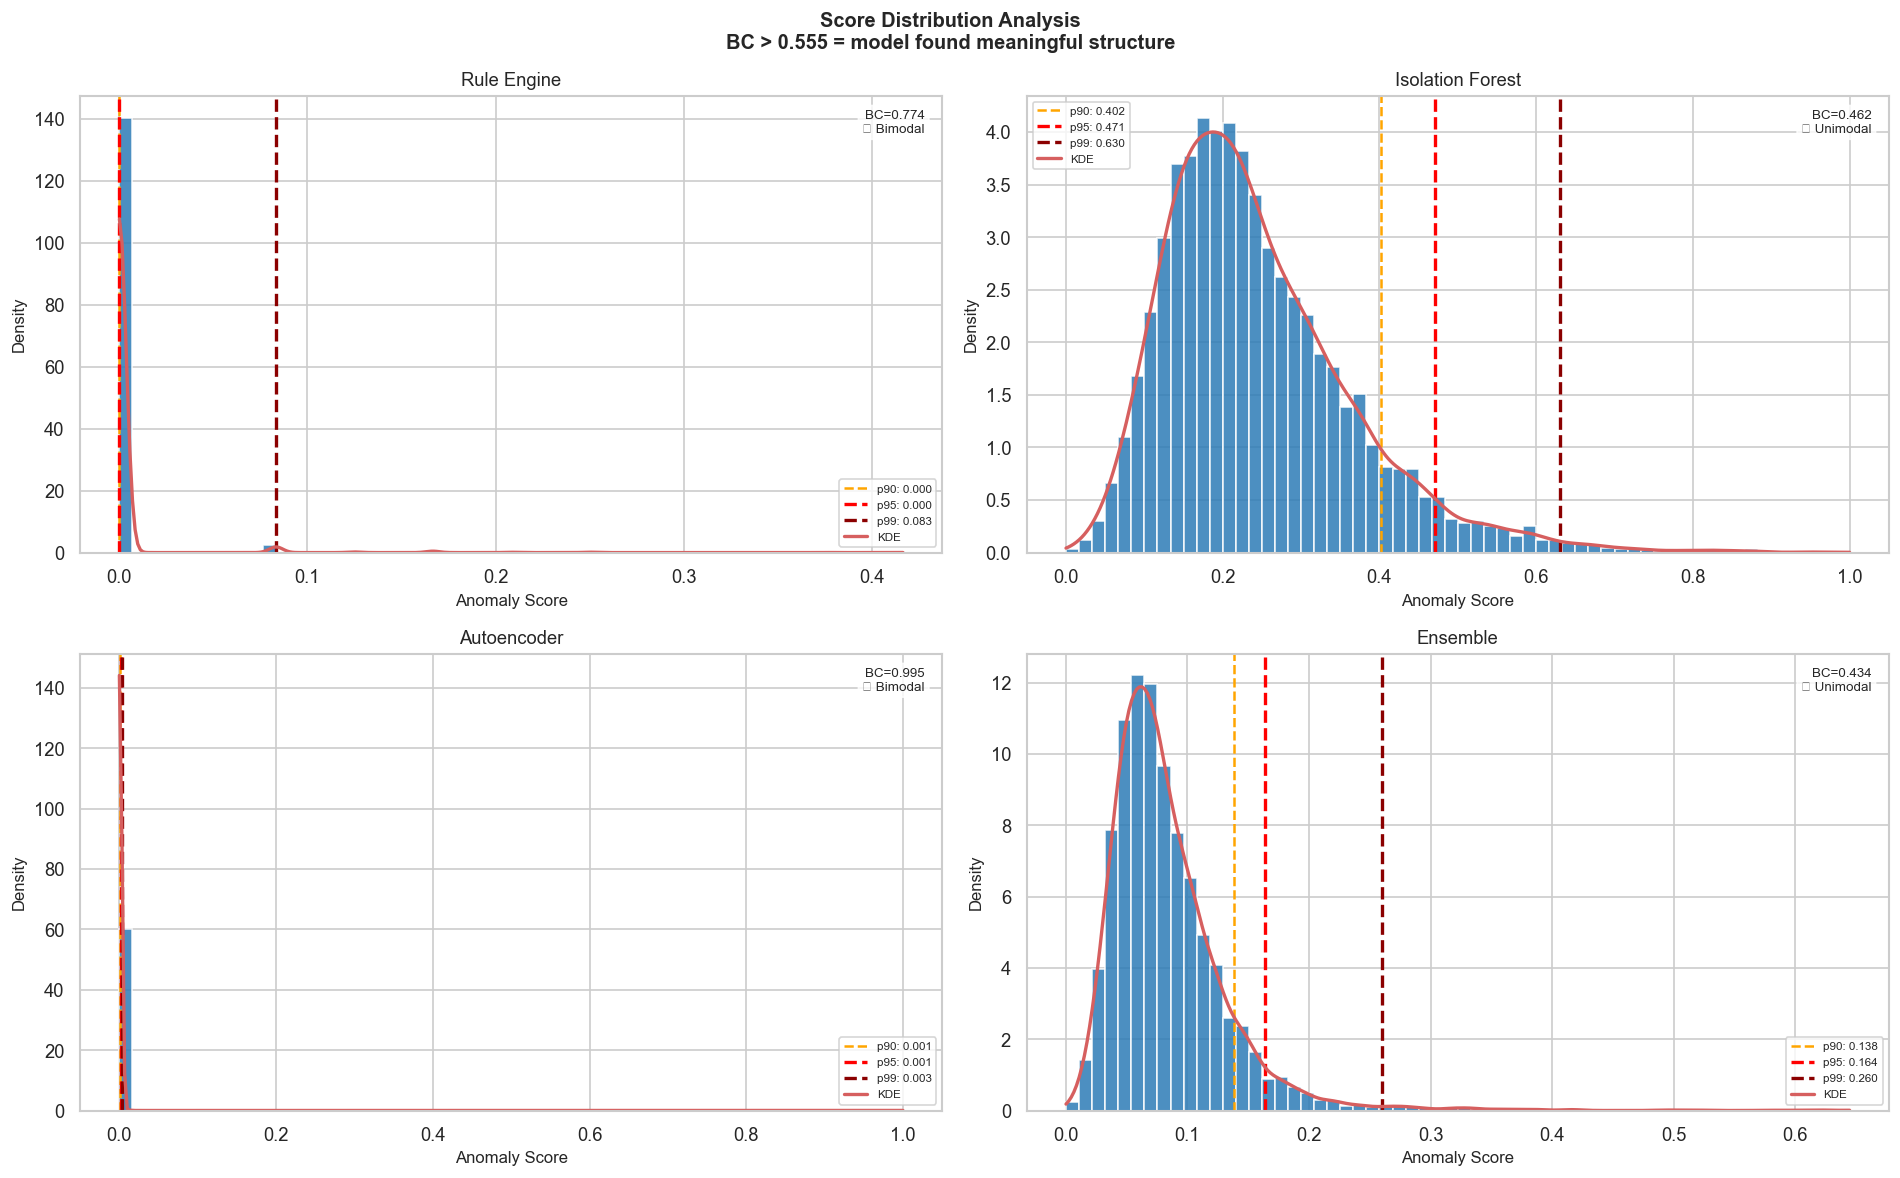


[Score Distribution Analysis]
  Model                       BC     Structure       p95    Sep.Ratio     Skew
  --------------------------------------------------------------------------
  Rule Engine              0.774     ✅ Bimodal    0.0000        infx     9.46
  Isolation Forest         0.462      Unimodal    0.4711       2.13x     1.24
  Autoencoder              0.995     ✅ Bimodal    0.0015       2.97x    61.84
  Ensemble                 0.434      Unimodal    0.1637       2.23x     2.79

── 2/3 Precision @ K ────────────────────────────────────────


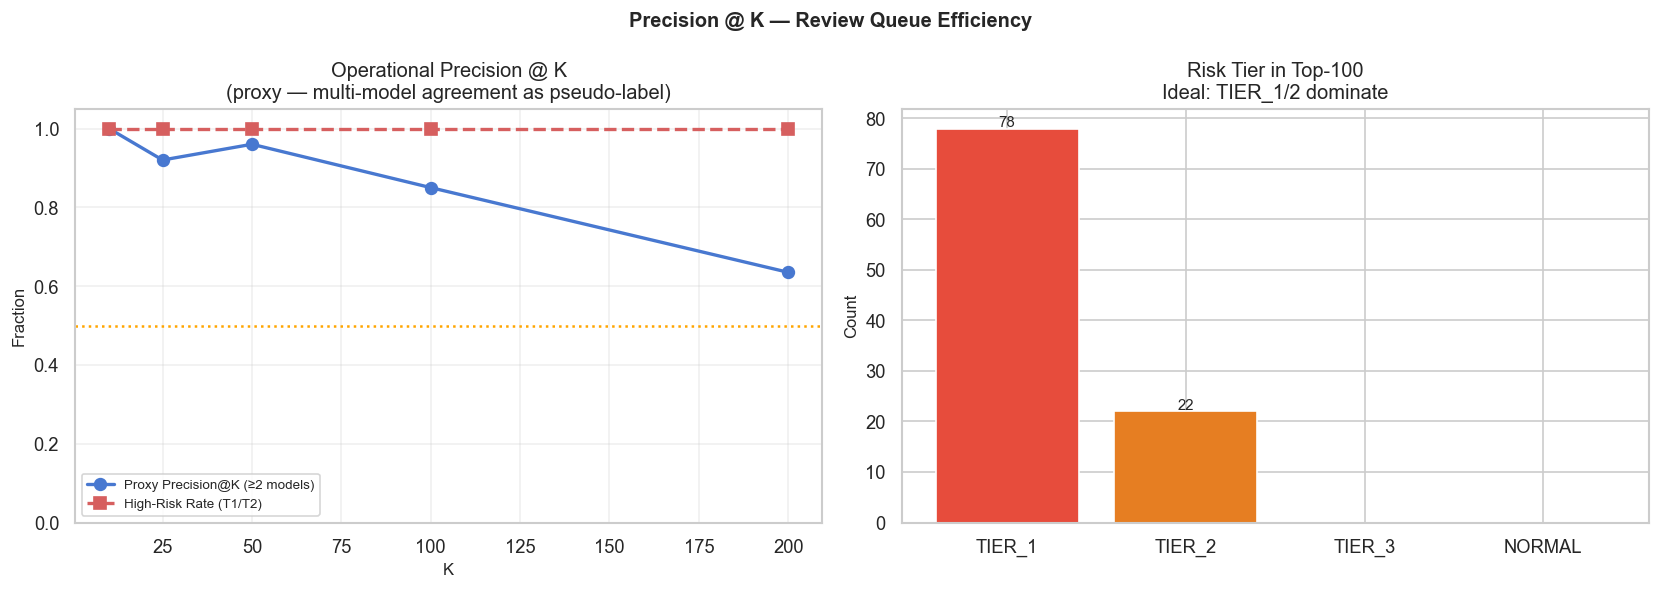


[Precision @ K]  (proxy_precision = lower bound — real fraud in queue unobserved)
  K  proxy_positives  proxy_precision@K  high_risk_in_top_K  high_risk_rate  mean_score
 10               10              1.000                  10             1.0      0.5504
 25               23              0.920                  25             1.0      0.4481
 50               48              0.960                  50             1.0      0.3842
100               85              0.850                 100             1.0      0.3234
200              127              0.635                 200             1.0      0.2676

── 3/3 Cross-Model Agreement ────────────────────────────────


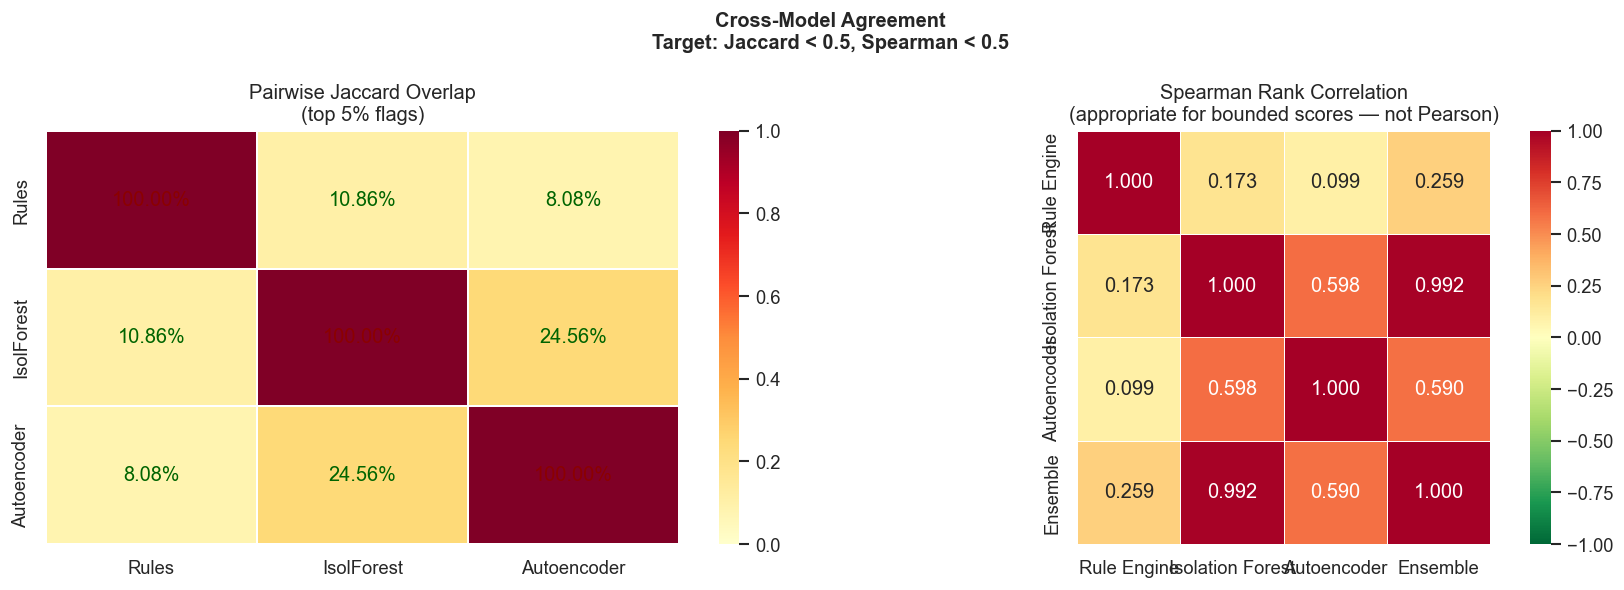


[Cross-Model Agreement]
  Jaccard overlap (top 5%):
             Rules  IsolForest  Autoencoder
Rules        1.000       0.109        0.081
IsolForest   0.109       1.000        0.246
Autoencoder  0.081       0.246        1.000

  Spearman rank correlations:
                  Rule Engine  Isolation Forest  Autoencoder  Ensemble
Rule Engine             1.000             0.173        0.099     0.259
Isolation Forest        0.173             1.000        0.598     0.992
Autoencoder             0.099             0.598        1.000     0.590
Ensemble                0.259             0.992        0.590     1.000

  IF ↔ AE       : Spearman=+0.598  ⚠ Correlated
  IF ↔ Rules    : Spearman=+0.173  ✅ Independent
  AE ↔ Rules    : Spearman=+0.099  ✅ Independent

  EVALUATION SUMMARY
  Rule Engine            BC=0.774  ✅ Bimodal
  Isolation Forest       BC=0.462  ⚠ Unimodal
  Autoencoder            BC=0.995  ✅ Bimodal
  Ensemble               BC=0.434  ⚠ Unimodal


In [72]:
if_detector = load_isolation_forest()
ae_detector = load_autoencoder()
eval_results = run_full_evaluation(final_df,if_detector,ae_detector )

#### <b>Model Stability</b>

In [73]:
def compute_csi( reference, comparison, bins,score_name,plot=True):
    """
    Industry interpretation thresholds:
        CSI < 0.10  — No significant shift, model is stable
        CSI 0.10–0.25 — Minor shift, monitor closely
        CSI > 0.25  — Major shift, model recalibration likely needed
    """
    ref = np.array(reference, dtype=float)
    cmp = np.array(comparison, dtype=float)

    # Remove NaN
    ref = ref[~np.isnan(ref)]
    cmp = cmp[~np.isnan(cmp)]

    # Use quantile-based bins from reference so each bin has equal population
    quantiles  = np.linspace(0, 100, bins + 1)
    bin_edges  = np.unique(np.percentile(ref, quantiles))
    # Ensure full coverage
    bin_edges[0]  = min(ref.min(), cmp.min()) - 1e-9
    bin_edges[-1] = max(ref.max(), cmp.max()) + 1e-9

    actual_bins = len(bin_edges) - 1

    # ── Count observations per bin ─────────────────────────────────────────────
    ref_counts = np.histogram(ref, bins=bin_edges)[0]
    cmp_counts = np.histogram(cmp, bins=bin_edges)[0]

    # Convert to proportions
    ref_pct = ref_counts / ref_counts.sum()
    cmp_pct = cmp_counts / cmp_counts.sum()

    # ── Compute CSI per bin ────────────────────────────────────────────────────
    # Replace zeros to avoid log(0) — standard practice is to floor at 0.0001
    ref_pct_adj = np.where(ref_pct == 0, 1e-4, ref_pct)
    cmp_pct_adj = np.where(cmp_pct == 0, 1e-4, cmp_pct)

    csi_per_bin = (cmp_pct_adj - ref_pct_adj) * np.log(cmp_pct_adj / ref_pct_adj)
    total_csi   = float(np.sum(csi_per_bin))

    # ── Interpretation ─────────────────────────────────────────────────────────
    if total_csi < 0.10:
        interpretation = "Stable — no action needed"
        interp_color   = "#2ecc71"
    elif total_csi < 0.25:
        interpretation = "Minor shift — monitor closely"
        interp_color   = "#f39c12"
    else:
        interpretation = "Major shift — recalibrate model"
        interp_color   = "#e74c3c"

    # ── Per-bin DataFrame ──────────────────────────────────────────────────────
    bin_labels = [
        f"{bin_edges[i]:.3f}–{bin_edges[i+1]:.3f}"
        for i in range(actual_bins)
    ]
    bin_df = pd.DataFrame({
        "bin":            bin_labels,
        "ref_count":      ref_counts,
        "cmp_count":      cmp_counts,
        "ref_pct":        (ref_pct * 100).round(2),
        "cmp_pct":        (cmp_pct * 100).round(2),
        "pct_diff":       ((cmp_pct - ref_pct) * 100).round(2),
        "csi_contribution": csi_per_bin.round(5),
    })

    # ── Print summary ──────────────────────────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"  CSI Report — {score_name}")
    print(f"{'='*55}")
    print(f"  Reference  : {len(ref):,} observations")
    print(f"  Comparison : {len(cmp):,} observations")
    print(f"  Bins       : {actual_bins}")
    print(f"  CSI        : {total_csi:.4f}")
    print(f"  Status     : {interpretation}")
    print(f"{'='*55}")
    print(bin_df.to_string(index=False))

    # ── Plot ───────────────────────────────────────────────────────────────────
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Distribution comparison
        x      = np.arange(actual_bins)
        width  = 0.4
        axes[0].bar(x - width/2, ref_pct * 100, width=width,
                    color="#3498db", alpha=0.85, label="Reference", edgecolor="white")
        axes[0].bar(x + width/2, cmp_pct * 100, width=width,
                    color="#e74c3c", alpha=0.85, label="Comparison", edgecolor="white")
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(
            [f"{bin_edges[i]:.2f}" for i in range(actual_bins)],
            rotation=45, ha="right", fontsize=7,
        )
        axes[0].set_ylabel("% of population")
        axes[0].set_title(f"{score_name} — Distribution Comparison", fontweight="bold")
        axes[0].legend(fontsize=9)

        # CSI contribution per bin
        bar_colors = [
            "#e74c3c" if v > 0.01 else "#f39c12" if v > 0.005 else "#2ecc71"
            for v in csi_per_bin
        ]
        axes[1].bar(x, csi_per_bin, color=bar_colors, edgecolor="white")
        axes[1].axhline(0, color="black", linewidth=0.8)
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(
            [f"{bin_edges[i]:.2f}" for i in range(actual_bins)],
            rotation=45, ha="right", fontsize=7,
        )
        axes[1].set_ylabel("CSI contribution")
        axes[1].set_title(
            f"CSI per Bin  |  Total CSI = {total_csi:.4f}\n{interpretation}",
            fontweight="bold", color=interp_color,
        )

        plt.suptitle(f"CSI Analysis — {score_name}", fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()

    return {
        "csi":            total_csi,
        "interpretation": interpretation,
        "bin_df":         bin_df,
        "bin_edges":      bin_edges,
    }


  CSI Report — Isolation Forest
  Reference  : 6,219 observations
  Comparison : 1,555 observations
  Bins       : 10
  CSI        : 0.1515
  Status     : Minor shift — monitor closely
         bin  ref_count  cmp_count  ref_pct  cmp_pct  pct_diff  csi_contribution
-0.000–0.110        622         43    10.00     2.77     -7.24           0.09303
 0.110–0.140        622         95    10.00     6.11     -3.89           0.01919
 0.140–0.166        622        143    10.00     9.20     -0.81           0.00068
 0.166–0.191        622        149    10.00     9.58     -0.42           0.00018
 0.191–0.216        621        173     9.99    11.13      1.14           0.00123
 0.216–0.244        622        185    10.00    11.90      1.90           0.00329
 0.244–0.279        622        178    10.00    11.45      1.45           0.00195
 0.279–0.327        622        225    10.00    14.47      4.47           0.01650
 0.327–0.404        622        221    10.00    14.21      4.21           0.01479
 0.4

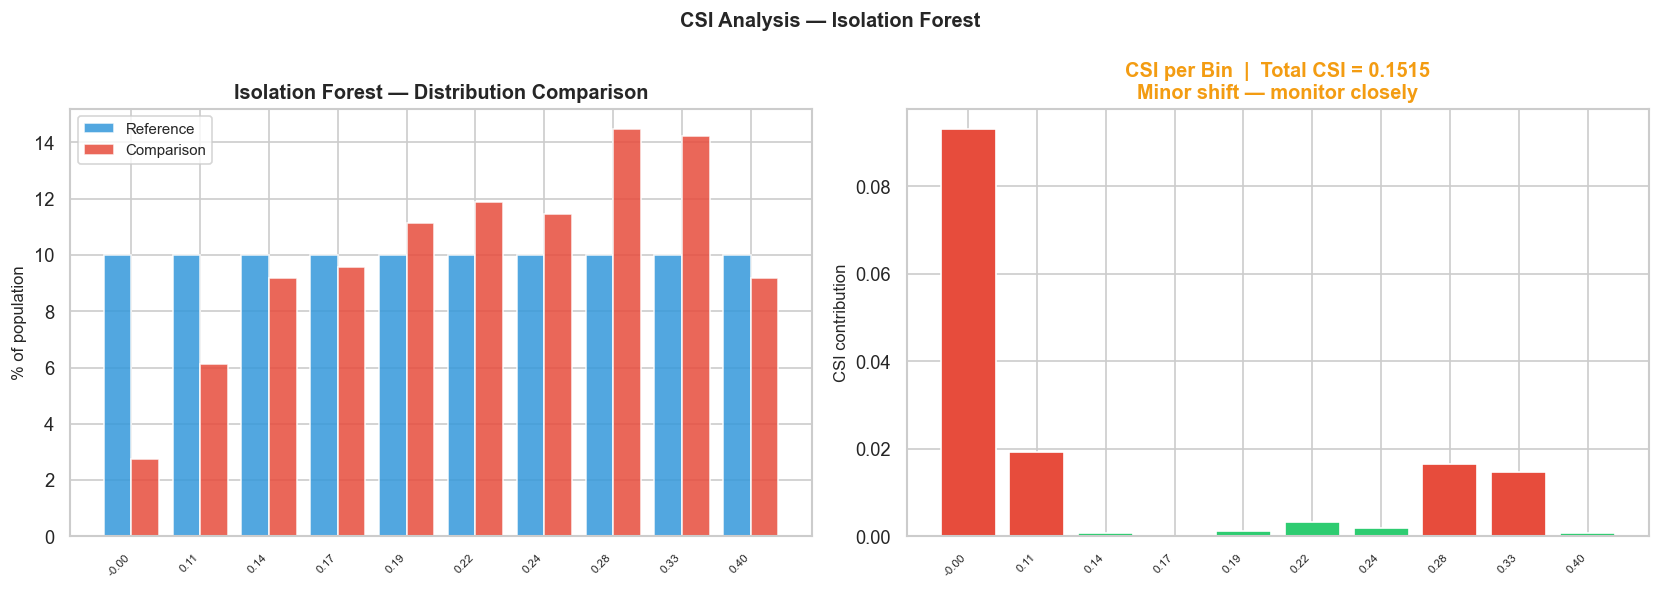

Isolation Forest: CSI = 0.1515 — Minor shift — monitor closely


  CSI Report — Autoencoder
  Reference  : 6,219 observations
  Comparison : 1,555 observations
  Bins       : 10
  CSI        : 0.2383
  Status     : Minor shift — monitor closely
         bin  ref_count  cmp_count  ref_pct  cmp_pct  pct_diff  csi_contribution
-0.000–0.000        622         37    10.00     2.38     -7.62           0.10945
 0.000–0.000        622         76    10.00     4.89     -5.11           0.03662
 0.000–0.000        622         96    10.00     6.17     -3.83           0.01847
 0.000–0.000        622        120    10.00     7.72     -2.28           0.00592
 0.000–0.000        621        156     9.99    10.03      0.05           0.00000
 0.000–0.001        622        182    10.00    11.70      1.70           0.00268
 0.001–0.001        622        206    10.00    13.25      3.25           0.00912
 0.001–0.001        622        240    10.00    15.43      5.43           0.02357
 0.001–0.001        622   

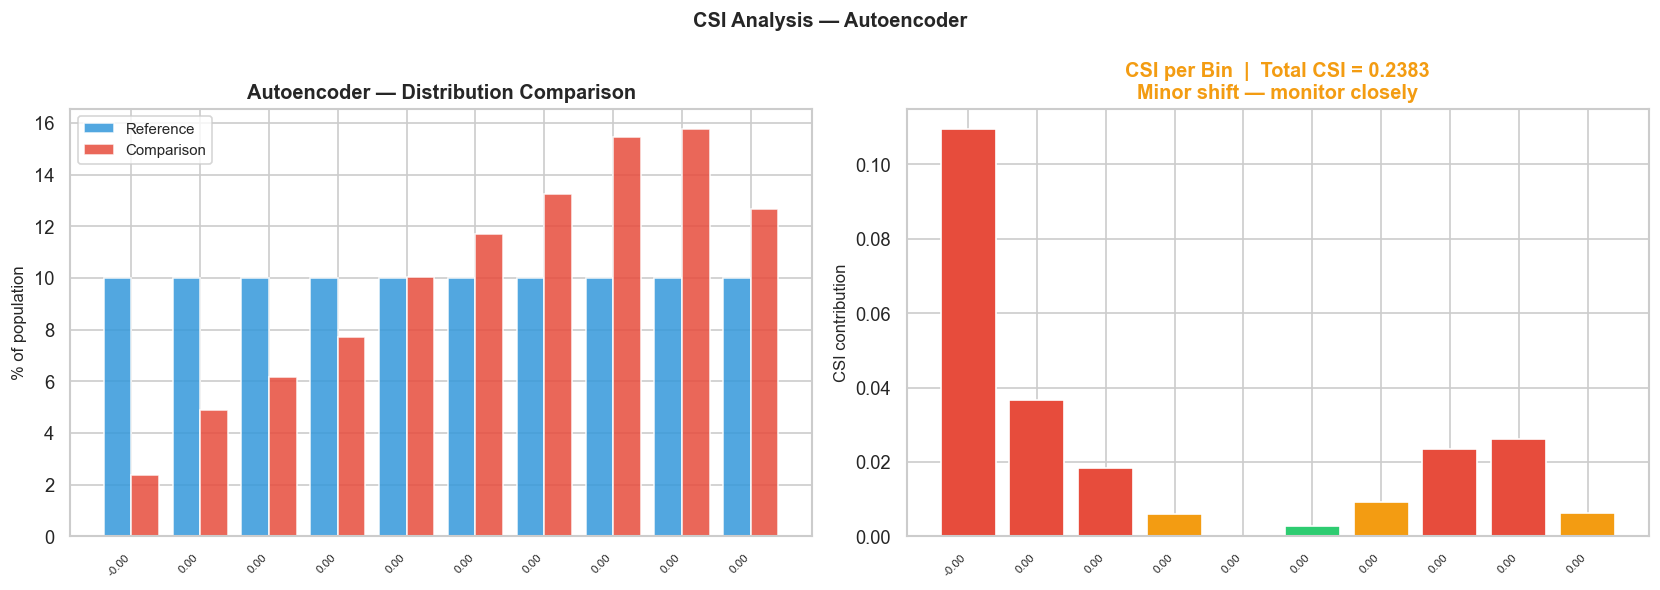

Autoencoder: CSI = 0.2383 — Minor shift — monitor closely


  CSI Report — Ensemble
  Reference  : 6,219 observations
  Comparison : 1,555 observations
  Bins       : 10
  CSI        : 0.1514
  Status     : Minor shift — monitor closely
        bin  ref_count  cmp_count  ref_pct  cmp_pct  pct_diff  csi_contribution
0.000–0.036        622         42    10.00     2.70     -7.30           0.09558
0.036–0.047        622         96    10.00     6.17     -3.83           0.01847
0.047–0.055        622        144    10.00     9.26     -0.74           0.00057
0.055–0.063        622        149    10.00     9.58     -0.42           0.00018
0.063–0.072        621        176     9.99    11.32      1.33           0.00167
0.072–0.081        622        183    10.00    11.77      1.77           0.00287
0.081–0.093        622        182    10.00    11.70      1.70           0.00268
0.093–0.111        622        242    10.00    15.56      5.56           0.02459
0.111–0.138        622        191    10.00 

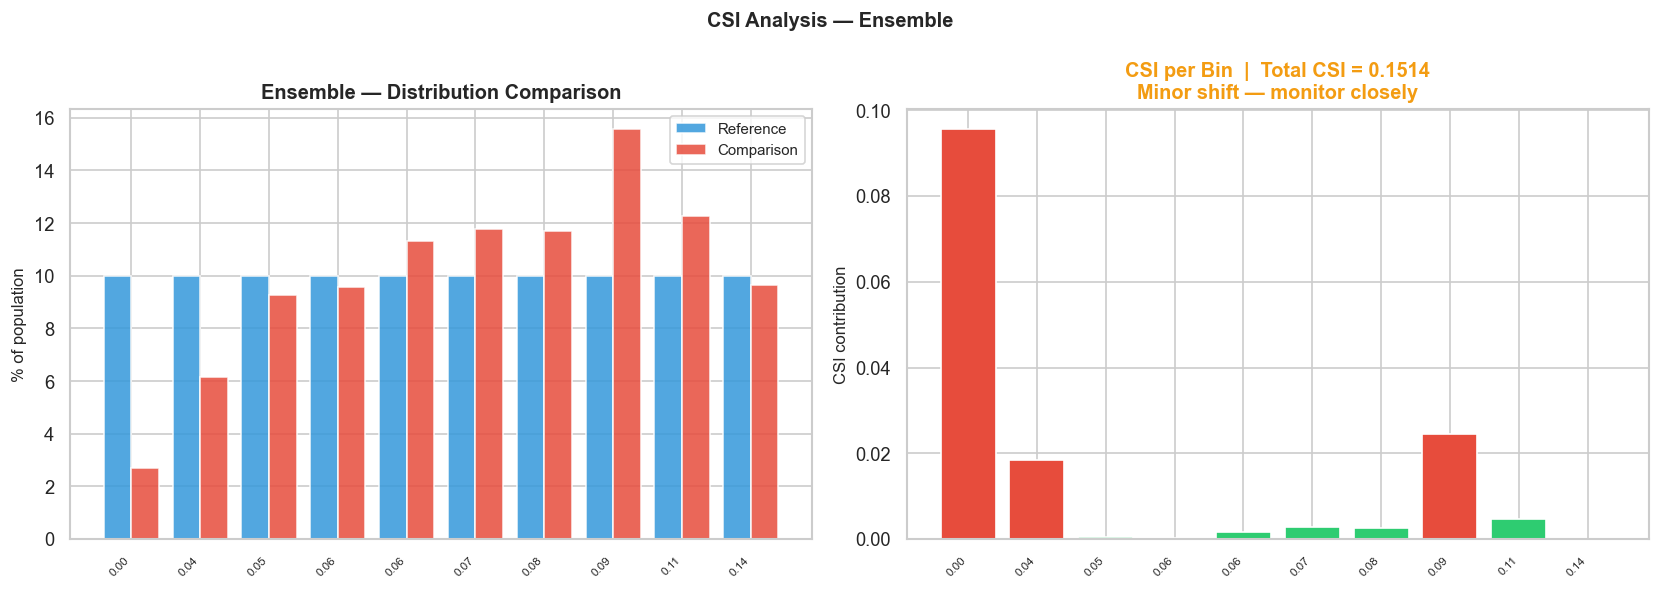

Ensemble: CSI = 0.1514 — Minor shift — monitor closely



In [76]:
ref_df = final_df[final_df["timestamp"] <= final_df["timestamp"].quantile(0.80)]
comp_df = final_df[final_df["timestamp"] > final_df["timestamp"].quantile(0.80)]

for col, label in [
    ("if_score",         "Isolation Forest"),
    ("ae_score",         "Autoencoder"),
    ("final_risk_score", "Ensemble"),
]:
    result = compute_csi(
        reference   = ref_df[col].values,
        comparison  = comp_df[col].values,
        score_name  = label,
        bins=10,
        plot        = True,
    )
    print(f"{label}: CSI = {result['csi']:.4f} — {result['interpretation']}\n")



## 7. Explainability — Per-Transaction Fraud Reports

For each high-risk transaction, we produce a structured investigation report combining:
- Rule flags with plain-English explanations
- SHAP feature importances (from Isolation Forest)
- Autoencoder per-feature reconstruction error
- Recommended business action


In [77]:
# ── Compute SHAP on all transactions (may take a moment) ─────────────────────
if_detector = load_isolation_forest()
ae_detector = load_autoencoder()
print("Computing SHAP values for all transactions...")
shap_matrix = if_detector.get_shap_values(final_df)

feature_names_list = if_detector.get_feature_names()
print(f"SHAP matrix shape: {shap_matrix.shape if shap_matrix is not None else 'N/A'}")


  SHAP explainer loaded from file.
✅ IsolationForest loaded ← outputs/model_artifacts
✅ Autoencoder (PyTorch) loaded ← outputs/model_artifacts
Computing SHAP values for all transactions...
SHAP matrix shape: (7774, 242)


In [78]:
# ── Generate fraud reports for top-10 highest risk transactions ─────────────
per_feature_recon_df = pd.read_csv('../data/final_scored/per_feature_recon_df.csv')
reports = generate_batch_reports(
    df=final_df,
    top_n=50,
    feature_names=feature_names_list,
    shap_matrix=shap_matrix,
    per_feature_recon_df=per_feature_recon_df if not per_feature_recon_df.empty else None,
)

for report in reports[:3]:   # Print first 3 in notebook
    print(report)



  ── RANK #1 by Risk Score ──
═════════════════════════════════════════════════════════════════
  FRAUD INVESTIGATION REPORT
═════════════════════════════════════════════════════════════════
  User     : user1050
  Time     : 2025-06-02 01:45:27
  Amount   : $3398.02
  City     : Birmingham
  Device   : Samsung Galaxy S10
  Txn Type : transfer
─────────────────────────────────────────────────────────────────
  RISK SCORE : 0.645  |  TIER: TIER_1  |  MODEL AGREEMENT: 2/3
─────────────────────────────────────────────────────────────────
  Model Detections:
    ⬜ Rule Engine       score=0.000
    ✅ Isolation Forest  score=0.944
    ✅ Autoencoder       score=0.980
─────────────────────────────────────────────────────────────────
  Rule Flags Triggered:
    → nan
─────────────────────────────────────────────────────────────────
  Top Features — Isolation Forest (SHAP):
    late_night_x_zscore_7D                 -0.22172  ↓ normal
    new_device_new_city_x_amt              -0.20132  ↓ norma

In [79]:
# Save all reports to file
os.makedirs("outputs", exist_ok=True)
with open("outputs/top_anomaly_reports.txt", "w") as f:
    for report in reports:
        f.write(report + "\\n")
print(f"Saved {len(reports)} fraud reports → outputs/top_anomaly_reports.txt")


Saved 50 fraud reports → outputs/top_anomaly_reports.txt


In [80]:
# Export results
top_n= 50
top_50 = final_df.sort_values("final_risk_score", ascending=False).head(top_n).reset_index(drop=True)
top_50.to_csv("outputs/top_50_anomalies.csv", index=False)
print(f"Top-50 risk score range: {top_50['final_risk_score'].min():.3f} – {top_50['final_risk_score'].max():.3f}")


Top-50 risk score range: 0.294 – 0.645


In [81]:
from src.explainability.visualiser import (
    plot_batch_statistics_table,
    plot_top50_anomalies,
)

In [82]:
stats = plot_batch_statistics_table(batch_final)
print(stats.to_string(index=False))

                 Tier  Count % of batch Avg risk score Avg amount (£) Rules fired Models agree ≥2
  TIER 1 — Auto Block     78       1.0%          0.345           3459          63              69
TIER 2 — Step-up Auth    311       4.0%          0.194           2975          78              79
     TIER 3 — Monitor   1551      20.0%          0.126           2822          56               1
               Normal   5834      75.0%          0.063           2349           0               0


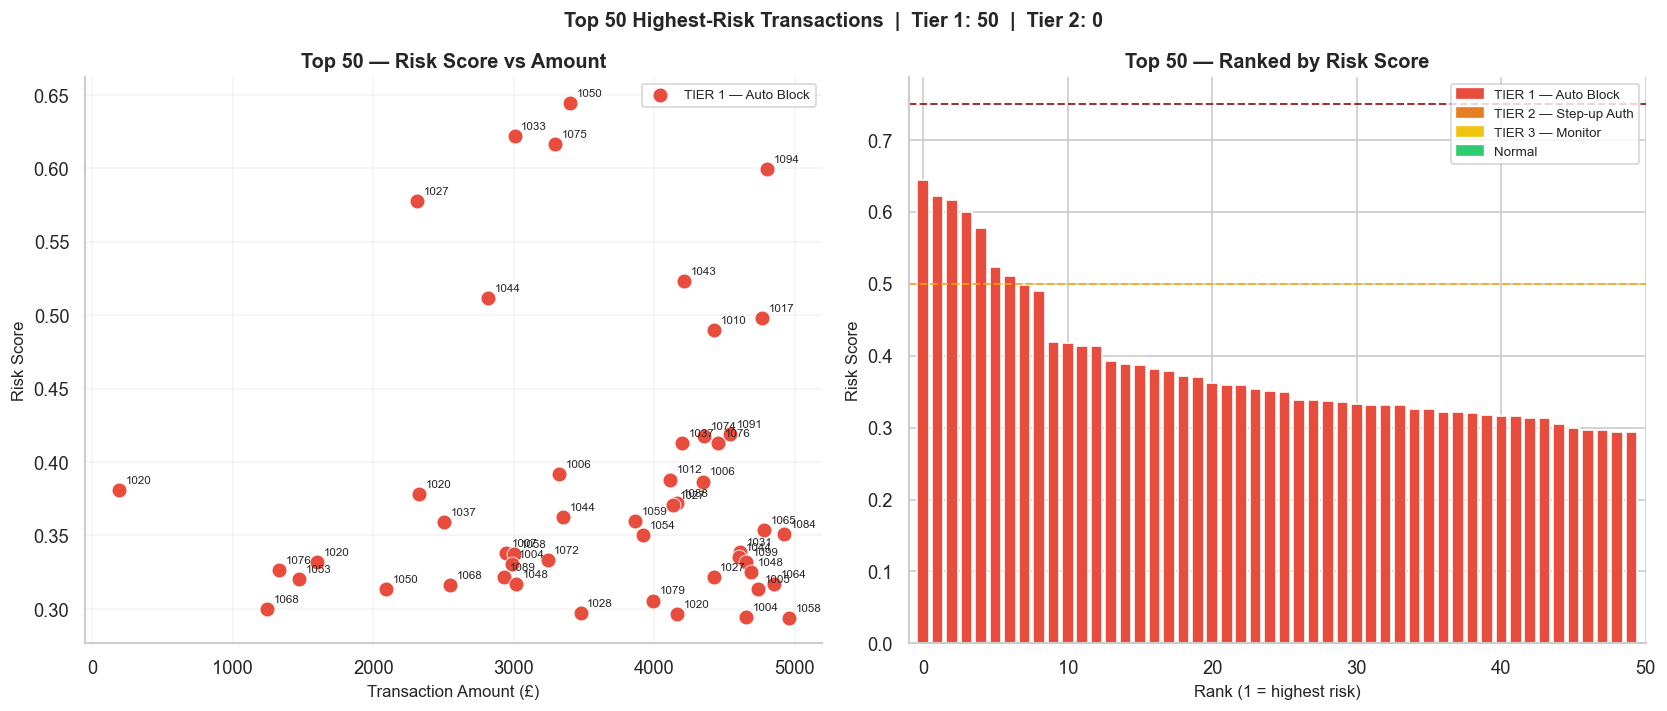

In [83]:
fig = plot_top50_anomalies(top_50)
plt.show()

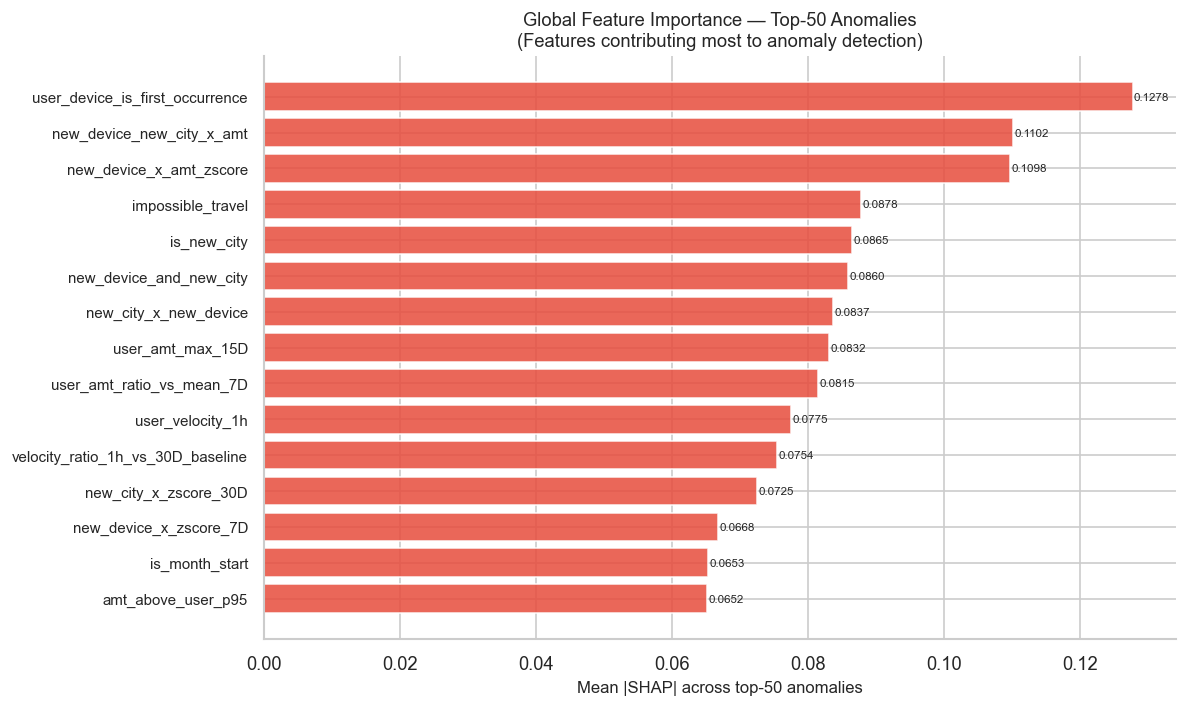

Saved → outputs/top50_feature_importance.png


In [84]:
if shap_matrix is not None:
    feature_names = if_det.get_feature_names()
    top50_idx = final_df.nlargest(50, "final_risk_score").index
    top50_pos = [final_df.index.get_loc(i) for i in top50_idx
                 if final_df.index.get_loc(i) < len(shap_matrix)]
    imp_top50 = shap_matrix[top50_pos]
    mean_imp  = np.abs(imp_top50).mean(axis=0)

    n     = min(len(feature_names), len(mean_imp))
    pairs = sorted(zip(feature_names[:n], mean_imp[:n]),
                   key=lambda x: x[1], reverse=True)[:15]
    names, vals = zip(*pairs)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(range(len(names)), vals, color="#e74c3c",
                   edgecolor="white", alpha=0.85)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel("Mean |SHAP| across top-50 anomalies")
    ax.set_title("Global Feature Importance — Top-50 Anomalies\n"
                 "(Features contributing most to anomaly detection)",
                 fontsize=11)
    ax.invert_yaxis()
    for bar, val in zip(bars, vals):
        ax.text(val + 0.0002, bar.get_y()+bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=7)
    plt.tight_layout()
    plt.savefig("outputs/top50_feature_importance.png", bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)
    print("Saved → outputs/top50_feature_importance.png")
else:
    print("SHAP matrix not available.")
